# Verify the soundness of 66 one-, two-, and three-qupit box relations
- Each derived relation is represented symbolically.
- We show that LHS and RHS correspond to the same symplectic matrix.
- Each test iterates over a list of primes—for example, `primes = [3, 5, 7, 11, 13, 19, 23]`—and check whether each derived relation holds for every prime. 

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')
import numpy as np

import math
import cmath
np.set_printoptions(precision = 5)

In [2]:
import matplotlib
import dizx
from dizx import Edge
from dizx import clifford_simplifier as simp

In [3]:
from sympy import symbols, Symbol, Add, Mul, sympify

def symbolic_inverse(x):
    x = sympify(x)

    # 0 has no inverse
    if x == 0:
        raise ValueError("0 has no multiplicative inverse.")

    # symbol → symbolinv
    if isinstance(x, Symbol):
        return symbols(f"{x.name}inv")

    # plain integer
    if x.is_Integer:
        if x == 1:
            return 1
        if x == -1:
            return -1
        return symbols(f"{x}inv")   # 3 → 3inv

    # product: coeff * symbol
    coeff, base = x.as_coeff_Mul()
    if isinstance(base, Symbol):
        inv_coeff = symbolic_inverse(coeff)
        inv_base  = symbols(f"{base.name}inv")
        return Mul(inv_coeff, inv_base, evaluate=True)  # <-- prevents concatenation

    # additive expression: invert whole block
    if isinstance(x, Add):
        return x**(-1)

    return x**(-1)

In [4]:
# # --- Define symbolic parameters ---
a, b, c, d, ab, binv, binvinv, ainv, ainvinv, g, aminus1, ginv, t, tinv = symbols("a b c d ab binv binvinv ainv ainvinv g aminus1 ginv t tinv")

params = [
    (a, ainv),
    (b, binv),
    (c, symbolic_inverse(c)),
    (d, symbolic_inverse(d)),
    (ab, symbolic_inverse(ab)),
    (binv, binvinv),
    (ainv, ainvinv),
    (g, ginv),
    (aminus1, symbolic_inverse(aminus1)),
    (t, tinv)
]

extra_relations = [ab - a * b, binvinv - b, ainvinv - a, aminus1 - (a - 1)]
extra_gens = [ab, binv, binvinv, ainv, ainvinv, aminus1]

In [5]:
"""Modules with tools for representing qudit Clifford matrices as symplectic matrices.
We are ignoring phases everywhere, and so everything is 'up to Paulis'.
The symplectic matrices are constructed according to the order (x1,z1,x2,z2,...) and hence not in terms of Z and X blocks.
"""
import os.path
from sympy import symbols, groebner, Matrix, eye, Symbol, mod_inverse, simplify, expand
from sympy import Matrix, groebner, Symbol
from typing import List, Tuple, Iterable, Optional
import dizx
from dizx.circuit.gates import SWAP, CZ, CX, HAD, S

Hmat = Matrix([[0,-1],[1,0]])
H2mat = Matrix([[-1,0],[0,-1]])
Hinvmat = Matrix([[0,1],[-1,0]])
idmat = Matrix([[1,0],[0,1]])
SWAPmat = Matrix([
                [0,0,1,0],
                [0,0,0,1],
                [1,0,0,0],
                [0,1,0,0]])

def Smat(rep):
    """Create a matrix representing `rep` repetitions of the S gate."""
    return Matrix([[1  ,0],
                   [rep,1]])

def MULmat(mul, dim):
    return Matrix([[mul,0],
                   [0,mod_inverse(mul,dim)]])

def CXmat(rep):
    return Matrix([
                [1  ,0,0,0],
                [0  ,1,0,-rep],
                [rep,0,1,0],
                [0  ,0,0,1]])

def CZmat(rep):
    return Matrix([
                [1  ,0,0  ,0],
                [0  ,1,rep,0],
                [0  ,0,1  ,0],
                [rep,0,0  ,1]])

def embed_block(block, n, mapping):
    """
    Embed a 2k x 2k symplectic 'block' into a 2n x 2n matrix.
    
    Parameters
    ----------
    block   : sympy.Matrix (2k x 2k)
              Symplectic block defined on local qudits [0..k-1],
              ordered [x0, z0, x1, z1, ...].
    n       : int
              Total number of qudits in the global system.
    mapping : list[int]
              Mapping of local qudits to global qudits.
              E.g. [2,4] means local 0 → global 2, local 1 → global 4.
    """
    k = len(mapping)
    assert block.shape == (2*k, 2*k)

    M = eye(2*n)

    # Local-to-global index map
    idx = []
    for q in mapping:
        idx.extend([2*q, 2*q+1])  # (x_q, z_q) in global basis order

    # Place the block into M
    for r in range(2*k):
        for c in range(2*k):
            M[idx[r], idx[c]] = block[r, c]

    return M

def ID(num_qudits):
    return eye(2*num_qudits)

def H(target, num_qudits, reps=1):
    if reps % 4 == 1: mat = Hmat
    elif reps % 4 == 2: mat = H2mat
    elif reps % 4 == 3: mat = Hinvmat
    else: mat = idmat
    return embed_block(mat, num_qudits, [target])

def MUL(target, num_qudits, mul, dim):
    mat = MULmat(mul, dim)
    return embed_block(mat, num_qudits, [target])

def S(target, num_qudits, reps=1):
    mat = Smat(reps)
    return embed_block(mat, num_qudits, [target])


def CX(control, target, num_qudits, reps=1):
    mat = CXmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def CZ(control, target, num_qudits, reps=1):
    mat = CZmat(reps)
    return embed_block(mat, num_qudits, [control,target])

def SWAP(control, target, num_qudits):
    return embed_block(SWAPmat, num_qudits, [control,target])

def modulo_matrix(M, p):
    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry = entry % p 
            newrow.append(entry)
        reduced_entries.append(newrow)
    # Test
    # print(p)
    return Matrix(reduced_entries)

def reduce_matrix(
    M: Matrix,
    params: List[Tuple[Symbol, Symbol]],
    extra_relations: Optional[Iterable] = None,
    extra_gens: Optional[Iterable[Symbol]] = None,
):
    """
    Given a matrix containing parameters, reduces it by applying simple identities.
    `params` should be a list of tuples (param, invparam) where we interpret invparam = param^{-1}.
    
    extra_relations: additional polynomial equations (each == 0), e.g. [dminusa - (d - a)]
    extra_gens: extra generators to include in the Groebner basis, e.g. [dminusa]
    """

    # Base generators: parameters and their inverses
    flattened = [a for (a, ainv) in params] + [ainv for (a, ainv) in params]

    # Add any extra generators (like dminusa)

    if extra_gens is not None:
        flattened += list(extra_gens)

    # --- Remove duplicate generators ---
    seen = set()
    flattened = [g for g in flattened if not (g in seen or seen.add(g))]


    # Base relations: a*ainv - 1 = 0
    relations = [a*ainv - 1 for (a, ainv) in params]

    # Add extra relations (like dminusa - (d - a) = 0)
    if extra_relations is not None:
        relations = relations + list(extra_relations)

    # Build Groebner basis
    G = groebner(relations, *flattened)

    reduced_entries = []
    for i in range(M.rows):
        row = M.row(i)
        newrow = []
        for entry in row:
            entry_red = G.reduce(entry)[1]
            newrow.append(entry_red)
        reduced_entries.append(newrow)

    return Matrix(reduced_entries)


def compare_matrices(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        m1 = modulo_matrix(m1,modulus)
        m2 = modulo_matrix(m2,modulus)
    return m1 == m2

def compare_matrices2(m1: Matrix, m2: Matrix, modulus: int = 0):
    if modulus != 0:
        a = symbols("a")
        ainv = symbols("ainv")
        b = symbols("b")
        binv = symbols("binv")
        m1_reduce = dizx.symplectic.reduce_matrix(m1,[(a,ainv),(b,binv)])
        m2_reduce = dizx.symplectic.reduce_matrix(m2,[(a,ainv),(b,binv)])
        m1_reduce = modulo_matrix(m1_reduce,modulus)
        m2_reduce = modulo_matrix(m2_reduce,modulus)
    return m1_reduce == m2_reduce

def compare_matrices3(
    m1: Matrix,
    m2: Matrix,
    params=None,
    modulus: int = 0,
    extra_relations=None,
    extra_gens=None
):
    """
    Compare two symplectic matrices after symbolic reductions and optional
    modulo arithmetic.

    Parameters
    ----------
    m1, m2 : sympy.Matrix
        Symplectic matrices to compare.

    params : list of (Symbol, Symbol)
        A list of parameter-inverse pairs (x, xinv), where xinv is interpreted
        as the formal multiplicative inverse of x.
        If None, no inverse reductions are applied.

    extra_relations : list of sympy expressions
        Additional algebraic constraints of the form expr == 0,
        e.g. [dminusa - (d - a), cminusb - (c - b)].
        These are added to the Groebner system.

    extra_gens : list of Symbols
        Additional generators to include in the Groebner basis.
        Required for composite parameters such as dminusa, cminusb.

    modulus : int
        If nonzero, reduce matrix entries modulo this integer.

    Returns
    -------
    bool
        True if the reduced matrices are equal, else False.
    """

    # --- Apply symbolic reduction (Groebner-based) ---
    if params is not None:
        m1 = reduce_matrix(
            m1,
            params=params,
            extra_relations=extra_relations,
            extra_gens=extra_gens,
        )
        m2 = reduce_matrix(
            m2,
            params=params,
            extra_relations=extra_relations,
            extra_gens=extra_gens,
        )

    # --- Optional modulus reduction ---
    if modulus != 0:
        m1 = modulo_matrix(m1, modulus)
        m2 = modulo_matrix(m2, modulus)

    # --- Compare matrices structurally ---
    return m1.equals(m2)

## Check the symplectic soundness of box relations
Print LHS and RHS to respective QASM files.

In [6]:
import os

def run_all_derived_relations(
    primes,
    save_to_path,
    params,
    relation_generator,
    extra_relations=None,
    extra_gens=None,
):
    """
    For each prime p:
        1. Generate BR relations via relation_generator(p)
        2. Compare LHS/RHS using compare_matrices3
        3. Save QASM outputs once after processing all primes

    Parameters
    ----------
    primes : iterable of ints
        Dimensions p of qudit Clifford theory to test.

    save_to_path : str
        Directory where QASM files will be written.

    params : list of (Symbol, Symbol)
        Formal inverse pairs, e.g. [(a, ainv), (b, binv), ...].

    relation_generator : callable
        Function taking p and returning (lhs_list, rhs_list, relation_names).

    extra_relations : list of SymPy expressions
        Additional symbolic constraints, e.g. [dminusa - (d - a)].

    extra_gens : list of Symbols
        Composite symbols appearing in extra_relations, e.g. [dminusa, cminusb].
    """

    # Ensure directory exists
    if not os.path.isdir(save_to_path):
        os.makedirs(save_to_path)

    # Will hold the final circuits for QASM output
    final_lhs_list = None
    final_rhs_list = None
    final_relation_names = None

    for p in primes:
        print(f"\n=== Checking BR relations for p = {p} ===")

        lhs_list, rhs_list, relation_names = relation_generator(p)

        # Store these so QASM export happens only once
        final_lhs_list = lhs_list
        final_rhs_list = rhs_list
        final_relation_names = relation_names

        for name, lhs, rhs in zip(relation_names, lhs_list, rhs_list):

            lhs_mat = lhs.to_symplectic_matrix()
            rhs_mat = rhs.to_symplectic_matrix()

            ok = compare_matrices3(
                lhs_mat,
                rhs_mat,
                params=params,
                modulus=p,
                extra_relations=extra_relations,
                extra_gens=extra_gens,
            )

            if ok:
                print(f"✔ {name} holds for p = {p}")
            else:
                print(f"❌ {name} fails for p = {p}")

    print("\n=== All primes processed ===")

    # Save QASM files ONCE (for the final prime)
    print(f"\nSaving QASM files to: {save_to_path}")

    for name, lhs, rhs in zip(final_relation_names, final_lhs_list, final_rhs_list):

        lhs_filename = os.path.join(save_to_path, f"{name}-lhs.qasm")
        rhs_filename = os.path.join(save_to_path, f"{name}-rhs.qasm")

        with open(lhs_filename, "w+") as f:
            f.write(lhs.to_qasm())

        with open(rhs_filename, "w+") as f:
            f.write(rhs.to_qasm())

    print("QASM files generated.")


## Generate all A boxes
- $A_{0b}$, $b \in \mathbb{Z}_p^*$
- $A_{ab}$, $a \in \mathbb{Z}_p^*$, $b \in \mathbb{Z}_p$

In [7]:
def instantiate_A_box(a, b, j, n, p):
    """
    Returns the A(a,b) box acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)

    # ---- Case A(0,b) ----
    if a == 0:
        circ += (
            HAD(j)**-1 +
            S(j)**symbolic_inverse(b) +
            HAD(j)**-1 +
            S(j)**b +
            HAD(j)
        )
        return circ

    # ---- Case A(a,b), a != 0 ----
    circ += (
        HAD(j)**-1 +
        S(j)**(-a) +
        HAD(j)**-1 +
        S(j)**(-symbolic_inverse(a)) +
        HAD(j)**-1 +
        S(j)**(-a * (b + 1)) +
        HAD(j)
    )
    return circ


In [8]:
def instantiate_multiplier(a, j, n, p):
    """
    Returns the multiplier Ma acting on qudit j inside an n-qudit circuit. Indexing starts from 0.
    """

    # ---- Index validation ----
    if not isinstance(j, int):
        raise TypeError(f"Target index j must be an integer, not {type(j)}.")

    if j < 0 or j >= n:
        raise ValueError(
            f"Target qudit index j={j} is out of range for n={n}. "
            f"Valid indices are 0 to {n-1}."
        )

    # ---- Create full circuit ----
    circ = dizx.Circuit(qudit_amount=n, dim=p)
    
    circ += (
        HAD(j) 
        + S(j)**a 
        + HAD(j) 
        + S(j)**symbolic_inverse(a) 
        + HAD(j) 
        + S(j)**a 
    )
    return circ

In [9]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37, 20]

M_binv = instantiate_multiplier(binv, 0, 1, 23)
M_binv_mat = M_binv.to_symplectic_matrix()
M_binv_red = reduce_matrix(M_binv_mat, params,extra_relations, extra_gens)
display(M_binv_mat)
display(M_binv_red)

Matrix([
[         binvinv,               -binv*binvinv + 1],
[binv*binvinv - 1, binv*(-binv*binvinv + 1) + binv]])

Matrix([
[binvinv,             0],
[      0, abinv*ainvinv]])

In [10]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37, 20]

for p in primes:
    Ma = instantiate_multiplier(a, 0, 1, p)
    Ma_mat = Ma.to_symplectic_matrix()
    Ma_red = reduce_matrix(Ma_mat, params)
    # display(Ma_mat)
    display(Ma_red)

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

Matrix([
[ainv,       0],
[   0, ainvinv]])

# Single-qupit Derived Relations

In [11]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S


def generate_single_qupit_derived_relations(p):
    """
    Generate all single-qupit derived relations R1 - R5 and D2 - D3 for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R1", "R2", ...]
    """
    # k = 5
    # --- instantiate multipliers ---
    M_minusa = instantiate_multiplier(-a, 0, 1, p)
    M_binv = instantiate_multiplier(binv, 0, 1, p)
    M_minusone = instantiate_multiplier(-1, 0, 1, p)
    Ma = instantiate_multiplier(a, 0, 1, p)
    M_ainv = instantiate_multiplier(ainv, 0, 1, p)
    # Mg = instantiate_multiplier(g, 0, 1, p)
    # Mgk = instantiate_multiplier(g**k, 0, 1, p)

    # --- Precompute Aab and A0b boxes used in the derived relations ---
    Aab = instantiate_A_box(a, b, 0, 1, p)
    A0b = instantiate_A_box(0, b, 0, 1, p)

    # --- Build BR relations ---

    # D2
    D2lhs = dizx.Circuit(qudit_amount=1, dim=p)
    D2rhs = dizx.Circuit(qudit_amount=1, dim=p)
    D2lhs += Aab
    D2rhs += M_minusa + HAD(0) ** 2 + S(0) ** (-ab) + HAD(0)
    # print("BR1lhs")
    # display(BR1lhs.draw())
    # print("BR1rhs")
    # display(BR1rhs.draw())

    # D3
    D3lhs = dizx.Circuit(qudit_amount=1, dim=p)
    D3rhs = dizx.Circuit(qudit_amount=1, dim=p)
    D3lhs += A0b
    D3rhs += M_binv + S(0) ** symbolic_inverse(-b)
    # print("D3lhs")
    # display(D3lhs.draw())
    # print("D3rhs")
    # display(D3rhs.draw())

    # R2
    R2lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R2rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R2lhs += HAD(0) ** 2
    R2rhs += M_minusone
    # print("R2lhs")
    # display(R2lhs.draw())
    # print("R2rhs")
    # display(R2rhs.draw())

    # R3
    R3lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R3rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R3lhs += S(0) + Ma 
    R3rhs += Ma + S(0) ** (a * a)
    # print("R3lhs")
    # display(R3lhs.draw())
    # print("R3rhs")
    # display(R3rhs.draw())

    # R3-1
    R3_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R3_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R3_1_lhs += Ma + S(0)
    R3_1_rhs += S(0) ** (ainv * ainv) + Ma
    # print("R3-1-lhs")
    # display(R3_1_lhs.draw())
    # print("R3-1-rhs")
    # display(R3_1_rhs.draw())

    # R3-2
    R3_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R3_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R3_2_lhs += HAD(0) ** 2 + S(0)
    R3_2_rhs += S(0) + HAD(0) ** 2
    # print("R3-2-lhs")
    # display(R3_2_lhs.draw())
    # print("R3-2-rhs")
    # display(R3_2_rhs.draw())

    # R4
    R4lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R4rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R4lhs += HAD(0) + Ma
    R4rhs += M_ainv + HAD(0)
    # print("R4lhs")
    # display(R4lhs.draw())
    # print("R4rhs")
    # display(R4rhs.draw())

    # R5
    # R5lhs = dizx.Circuit(qudit_amount=1, dim=p)
    # R5rhs = dizx.Circuit(qudit_amount=1, dim=p)

    # for j in range(k):
    #     R5lhs += Mg
    
    # R5rhs += Mgk

    # print("Multiplier power relation (LHS):")
    # display(R5lhs.draw())
    # R5lhs_mat = R5lhs.to_symplectic_matrix()
    # R5lhs_red = reduce_matrix(R5lhs_mat, params)
    # display(R5lhs_red)

    # print("Multiplier power relation (RHS):")
    # display(R5rhs.draw())
    # R5rhs_mat = R5rhs.to_symplectic_matrix()
    # R5rhs_red = reduce_matrix(R5rhs_mat, params)
    # display(R5rhs_red)


    
    # Put all circuits in order
    lhs_list = [D2lhs,D3lhs,R2lhs,R3lhs,R3_1_lhs,R3_2_lhs,R4lhs]
    rhs_list = [D2rhs,D3rhs,R2rhs,R3rhs,R3_1_rhs,R3_2_rhs,R4rhs]

    relation_names = ["D2","D3","R2","R3","R3-1","R3-2","R4"]

    return lhs_list, rhs_list, relation_names


In [12]:
generate_single_qupit_derived_relations(23)

([Circuit[23](1 qudits, 0 dits, [HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD^2(0)] gates),
  Circuit[23](1 qudits, 0 dits, [S(0), HAD(0), S^a(0), HAD(0), S^ainv(0), HAD(0), S^a(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD(0), S^a(0), HAD(0), S^ainv(0), HAD(0), S^a(0), S(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD^2(0), S(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD(0), HAD(0), S^a(0), HAD(0), S^ainv(0), HAD(0), S^a(0)] gates)],
 [Circuit[23](1 qudits, 0 dits, [HAD(0), S^-a(0), HAD(0), S^-ainv(0), HAD(0), S^-a(0), HAD^2(0), S^-ab(0), HAD(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD(0), S^binv(0), HAD(0), S^binvinv(0), HAD(0), S^binv(0), S^-binv(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD(0), S^-1(0), HAD(0), S^-1(0), HAD(0), S^-1(0)] gates),
  Circuit[23](1 qudits, 0 dits, [HAD(0), S^a(0), HAD(0), 

In [13]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ D2 holds for p = 3
✔ D3 holds for p = 3
✔ R2 holds for p = 3
✔ R3 holds for p = 3
✔ R3-1 holds for p = 3
✔ R3-2 holds for p = 3
✔ R4 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ D2 holds for p = 5
✔ D3 holds for p = 5
✔ R2 holds for p = 5
✔ R3 holds for p = 5
✔ R3-1 holds for p = 5
✔ R3-2 holds for p = 5
✔ R4 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ D2 holds for p = 7
✔ D3 holds for p = 7
✔ R2 holds for p = 7
✔ R3 holds for p = 7
✔ R3-1 holds for p = 7
✔ R3-2 holds for p = 7
✔ R4 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ D2 holds for p = 11
✔ D3 holds for p = 11
✔ R2 holds for p = 11
✔ R3 holds for p = 11
✔ R3-1 holds for p = 11
✔ R3-2 holds for p = 11
✔ R4 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ D2 holds for p = 13
✔ D3 holds for p = 13
✔ R2 holds for p = 13
✔ R3 holds for p = 13
✔ R3-1 holds for p = 13
✔ R3-2 holds for p = 13
✔ R4 holds for p = 13

=== Checking BR relatio

In [14]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_Mg_CZ(p):
    """
    Generate all two-qupit derived relations R6-R17 for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R6", "R7", ...]
    """
    # --- instantiate multipliers ---
    Mg_0 = instantiate_multiplier(g, 0, 2, p)
    Mg_1 = instantiate_multiplier(g, 1, 2, p)

    # --- Precompute Aab and A0b boxes used in the derived relations ---
    # Aab = instantiate_A_box(a, b, 0, 1, p)
    # A0b = instantiate_A_box(0, b, 0, 1, p)

    # --- Build BR relations ---

    # R9
    R9lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9lhs += Mg_0 + CZ(0,1)
    R9rhs += CZ(0,1) ** ginv + Mg_0
    # R9lhs_mat = R9lhs.to_symplectic_matrix()
    # R9lhs_red = reduce_matrix(R9lhs_mat, params)
    # display(R9lhs_red)
    # R9rhs_mat = R9rhs.to_symplectic_matrix()
    # R9rhs_red = reduce_matrix(R9rhs_mat, params)
    # display(R9rhs_red)
    # print("R9lhs")
    # display(R9lhs.draw())
    # print("R9rhs")
    # display(R9rhs.draw())

    # R9-1
    R9_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_1_lhs += CZ(0,1) + Mg_0
    R9_1_rhs += Mg_0 + CZ(0,1) ** g
    # print("R9-1-lhs")
    # display(R9_1_lhs.draw())
    # print("R9-1-rhs")
    # display(R9_1_rhs.draw())

    # R9-2
    R9_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_2_lhs += Mg_1 + CZ(0,1)
    R9_2_rhs += CZ(0,1) ** ginv + Mg_1
    # print("R9-2-lhs")
    # display(R9_2_lhs.draw())
    # print("R9-2-rhs")
    # display(R9_2_rhs.draw())

    # R9-3
    R9_3_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_3_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_3_lhs += CZ(0,1) +  Mg_1
    R9_3_rhs += Mg_1 + CZ(0,1) ** g
    # print("R9-3-lhs")
    # display(R9_3_lhs.draw())
    # print("R9-3-rhs")
    # display(R9_3_rhs.draw())

    # R9-4
    R9_4_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_4_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_4_lhs += HAD(0) ** 2 + CZ(0,1)
    R9_4_rhs += CZ(0,1) ** (-1) + HAD(0) ** 2
    # print("R9-4-lhs")
    # display(R9_4_lhs.draw())
    # print("R9-4-rhs")
    # display(R9_4_rhs.draw())

    # R9-5
    R9_5_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_5_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_5_lhs += CZ(0,1) + HAD(0) ** 2
    R9_5_rhs += HAD(0) ** 2 + CZ(0,1) ** (-1)
    # print("R9-5-lhs")
    # display(R9_5_lhs.draw())
    # print("R9-5-rhs")
    # display(R9_5_rhs.draw())

    # R9-6
    R9_6_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_6_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_6_lhs += HAD(1) ** 2 + CZ(0,1)
    R9_6_rhs += CZ(0,1) ** (-1) + HAD(1) ** 2
    # print("R9-6-lhs")
    # display(R9_6_lhs.draw())
    # print("R9-6-rhs")
    # display(R9_6_rhs.draw())

    # R9-7
    R9_7_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_7_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_7_lhs += CZ(0,1) + HAD(1) ** 2
    R9_7_rhs += HAD(1) ** 2 + CZ(0,1) ** (-1)
    # print("R9-7-lhs")
    # display(R9_7_lhs.draw())
    # print("R9-7-rhs")
    # display(R9_7_rhs.draw())

    # R9-8
    R9_8_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_8_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_8_lhs += Mg_0 + CX(0,1)
    R9_8_rhs += CX(0,1) ** ginv + Mg_0
    # print("R9-8-lhs")
    # display(R9_8_lhs.draw())
    # print("R9-8-rhs")
    # display(R9_8_rhs.draw())

    # R9-9
    R9_9_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_9_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_9_lhs += CX(0,1) + Mg_0
    R9_9_rhs += Mg_0 + CX(0,1) ** g
    # print("R9-9-lhs")
    # display(R9_9_lhs.draw())
    # print("R9-9-rhs")
    # display(R9_9_rhs.draw())

    # R9-10
    R9_10_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_10_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_10_lhs += Mg_1 + CX(0,1)
    R9_10_rhs += CX(0,1) ** g + Mg_1
    # print("R9-10-lhs")
    # display(R9_10_lhs.draw())
    # print("R9-10-rhs")
    # display(R9_10_rhs.draw())

    # R9lhs_mat = R9lhs.to_symplectic_matrix()
    # R9lhs_red = reduce_matrix(R9lhs_mat, params)
    # display(R9lhs_red)

    # R9_10_rhs_mat = R9_10_rhs.to_symplectic_matrix()
    # R9_10_rhs_red = reduce_matrix(R9_10_rhs_mat, params)
    # display(R9_10_rhs_red)
    # print("R9_10_lhs")
    # display(R9_10_lhs.draw())
    # print("R9_10_rhs")
    # display(R9_10_rhs.draw())

    # R9-11
    R9_11_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_11_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_11_lhs += CX(0,1) + Mg_1
    R9_11_rhs += Mg_1 + CX(0,1) ** ginv
    # print("R9-11-lhs")
    # display(R9_11_lhs.draw())
    # print("R9-11-rhs")
    # display(R9_11_rhs.draw())

    # R9-12
    R9_12_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_12_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_12_lhs += Mg_0 + CZ(0,1) ** a
    R9_12_rhs += CZ(0,1) ** (a * ginv) + Mg_0
    # print("R9-12-lhs")
    # display(R9_12_lhs.draw())
    # print("R9-12-rhs")
    # display(R9_12_rhs.draw())

    # R9-13
    R9_13_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_13_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_13_lhs += CZ(0,1) ** a + Mg_0
    R9_13_rhs += Mg_0 + CZ(0,1) ** (a * g)
    # print("R9-13-lhs")
    # display(R9_13_lhs.draw())
    # print("R9-13-rhs")
    # display(R9_13_rhs.draw())

    # R9-14
    R9_14_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_14_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_14_lhs += Mg_1 + CZ(0,1) ** a
    R9_14_rhs += CZ(0,1) ** (a * ginv) + Mg_1
    # print("R9-14-lhs")
    # display(R9_14_lhs.draw())
    # print("R9-14-rhs")
    # display(R9_14_rhs.draw())

    # R9-15
    R9_15_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_15_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_15_lhs += CZ(0,1) ** a + Mg_1
    R9_15_rhs += Mg_1 + CZ(0,1) ** (a * g)
    # print("R9-15-lhs")
    # display(R9_15_lhs.draw())
    # print("R9-15-rhs")
    # display(R9_15_rhs.draw())

    # R9-16
    R9_16_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_16_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_16_lhs += Mg_0 + CX(0,1) ** a
    R9_16_rhs += CX(0,1) ** (a * ginv) + Mg_0
    # print("R9-16-lhs")
    # display(R9_16_lhs.draw())
    # print("R9-16-rhs")
    # display(R9_16_rhs.draw())

    # R9-17
    R9_17_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_17_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_17_lhs += CX(0,1) ** a + Mg_0
    R9_17_rhs += Mg_0 + CX(0,1) ** (a * g)
    # print("R9-17-lhs")
    # display(R9_17_lhs.draw())
    # print("R9-17-rhs")
    # display(R9_17_rhs.draw())

    # R9-18
    R9_18_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_18_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_18_lhs += Mg_1 + CX(0,1) ** a
    R9_18_rhs += CX(0,1) ** (a * g) + Mg_1
    # print("R9-18-lhs")
    # display(R9_18_lhs.draw())
    # print("R9-18-rhs")
    # display(R9_18_rhs.draw())

    # R9-19
    R9_19_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_19_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_19_lhs += CX(0,1) ** a + Mg_1
    R9_19_rhs += Mg_1 + CX(0,1) ** (a * ginv)
    # print("R9-19-lhs")
    # display(R9_19_lhs.draw())
    # print("R9-19-rhs")
    # display(R9_19_rhs.draw())

    
    # Put all circuits in order
    lhs_list = [R9lhs, R9_1_lhs, R9_2_lhs, R9_3_lhs, R9_4_lhs, R9_5_lhs, R9_6_lhs, R9_7_lhs, R9_8_lhs, R9_9_lhs, R9_10_lhs, R9_11_lhs, R9_12_lhs, R9_13_lhs, R9_14_lhs, R9_15_lhs, R9_16_lhs, R9_17_lhs, R9_18_lhs, R9_19_lhs]
    rhs_list = [R9rhs, R9_1_rhs, R9_2_rhs, R9_3_rhs, R9_4_rhs, R9_5_rhs, R9_6_rhs, R9_7_rhs, R9_8_rhs, R9_9_rhs, R9_10_rhs, R9_11_rhs, R9_12_rhs, R9_13_rhs, R9_14_rhs, R9_15_rhs, R9_16_rhs, R9_17_rhs, R9_18_rhs, R9_19_rhs]

    relation_names = ["R9", "R9-1", "R9-2", "R9-3", "R9-4", "R9-5", "R9-6", "R9-7", "R9-8", "R9-9", "R9-10", "R9-11", "R9-12", "R9-13", "R9-14", "R9-15", "R9-16", "R9-17", "R9-18", "R9-19"]

    return lhs_list, rhs_list, relation_names


In [15]:
generate_Mg_CZ(23)

([Circuit[23](2 qudits, 0 dits, [HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD(1), S^g

In [16]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R9 holds for p = 3
✔ R9-1 holds for p = 3
✔ R9-2 holds for p = 3
✔ R9-3 holds for p = 3
✔ R9-4 holds for p = 3
✔ R9-5 holds for p = 3
✔ R9-6 holds for p = 3
✔ R9-7 holds for p = 3
✔ R9-8 holds for p = 3
✔ R9-9 holds for p = 3
✔ R9-10 holds for p = 3
✔ R9-11 holds for p = 3
✔ R9-12 holds for p = 3
✔ R9-13 holds for p = 3
✔ R9-14 holds for p = 3
✔ R9-15 holds for p = 3
✔ R9-16 holds for p = 3
✔ R9-17 holds for p = 3
✔ R9-18 holds for p = 3
✔ R9-19 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R9 holds for p = 5
✔ R9-1 holds for p = 5
✔ R9-2 holds for p = 5
✔ R9-3 holds for p = 5
✔ R9-4 holds for p = 5
✔ R9-5 holds for p = 5
✔ R9-6 holds for p = 5
✔ R9-7 holds for p = 5
✔ R9-8 holds for p = 5
✔ R9-9 holds for p = 5
✔ R9-10 holds for p = 5
✔ R9-11 holds for p = 5
✔ R9-12 holds for p = 5
✔ R9-13 holds for p = 5
✔ R9-14 holds for p = 5
✔ R9-15 holds for p = 5
✔ R9-16 holds for p = 5
✔ R9-17 holds for p = 5
✔ R9-18 holds for p = 5
✔ R9-1

In [17]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_Mg_CZ_refl(p):
    """
    Generate two-qupit derived relations R9-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R9-20", "R9-21", ...]
    """
    # --- instantiate multipliers ---
    Mg_0 = instantiate_multiplier(g, 0, 2, p)
    Mg_1 = instantiate_multiplier(g, 1, 2, p)

    # --- Build derived relations ---

    # R9-20
    R9_20_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_20_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_20_lhs += Mg_1 + CX(1,0)
    R9_20_rhs += CX(1,0) ** ginv + Mg_1
    # print("R9-20-lhs")
    # display(R9_20_lhs.draw())
    # print("R9-20-rhs")
    # display(R9_20_rhs.draw())

    # R9-21
    R9_21_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_21_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_21_lhs += CX(1,0) + Mg_1
    R9_21_rhs += Mg_1 + CX(1,0) ** g
    # print("R9-21-lhs")
    # display(R9_21_lhs.draw())
    # print("R9-21-rhs")
    # display(R9_21_rhs.draw())

    # R9-22
    R9_22_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_22_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_22_lhs += Mg_0 + CX(1,0)
    R9_22_rhs += CX(1,0) ** g + Mg_0
    # print("R9-22-lhs")
    # display(R9_22_lhs.draw())
    # print("R9-22-rhs")
    # display(R9_22_rhs.draw())

    # R9-23
    R9_23_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_23_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_23_lhs += CX(1,0) + Mg_0
    R9_23_rhs += Mg_0 + CX(1,0) ** ginv
    # print("R9-23-lhs")
    # display(R9_23_lhs.draw())
    # print("R9-23-rhs")
    # display(R9_23_rhs.draw())

    # R9-24
    R9_24_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_24_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_24_lhs += Mg_1 + CX(1,0) ** a
    R9_24_rhs += CX(1,0) ** (a * ginv) + Mg_1
    # print("R9-24-lhs")
    # display(R9_24_lhs.draw())
    # print("R9-24-rhs")
    # display(R9_24_rhs.draw())

    # R9-25
    R9_25_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_25_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_25_lhs += CX(1,0) ** a + Mg_1
    R9_25_rhs += Mg_1 + CX(1,0) ** (a * g)
    # print("R9-25-lhs")
    # display(R9_25_lhs.draw())
    # print("R9-25-rhs")
    # display(R9_25_rhs.draw())

    # R9-26
    R9_26_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_26_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_26_lhs += Mg_0 + CX(1,0) ** a
    R9_26_rhs += CX(1,0) ** (a * g) + Mg_0
    # print("R9-26-lhs")
    # display(R9_26_lhs.draw())
    # print("R9-26-rhs")
    # display(R9_26_rhs.draw())

    # R9-27
    R9_27_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_27_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_27_lhs += CX(1,0) ** a + Mg_0
    R9_27_rhs += Mg_0 + CX(1,0) ** (a * ginv)
    # print("R9-27-lhs")
    # display(R9_27_lhs.draw())
    # print("R9-27-rhs")
    # display(R9_27_rhs.draw())

    
    # Put all circuits in order
    lhs_list = [R9_20_lhs, R9_21_lhs, R9_22_lhs, R9_23_lhs, R9_24_lhs, R9_25_lhs, R9_26_lhs, R9_27_lhs]
    rhs_list = [R9_20_rhs, R9_21_rhs, R9_22_rhs, R9_23_rhs, R9_24_rhs, R9_25_rhs, R9_26_rhs, R9_27_rhs]

    relation_names = ["R9-20", "R9-21", "R9-22", "R9-23", "R9-24", "R9-25", "R9-26", "R9-27"]

    return lhs_list, rhs_list, relation_names


In [18]:
generate_Mg_CZ_refl(23)

([Circuit[23](2 qudits, 0 dits, [HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD(0), S^g(0), HAD(0), S^ginv(0), HAD(0), S^g(0)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX^ginv(1,0), HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S^g(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), S^g(1), HAD(1), S^ginv(1), HAD(1), S

In [19]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R9-20 holds for p = 3
✔ R9-21 holds for p = 3
✔ R9-22 holds for p = 3
✔ R9-23 holds for p = 3
✔ R9-24 holds for p = 3
✔ R9-25 holds for p = 3
✔ R9-26 holds for p = 3
✔ R9-27 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R9-20 holds for p = 5
✔ R9-21 holds for p = 5
✔ R9-22 holds for p = 5
✔ R9-23 holds for p = 5
✔ R9-24 holds for p = 5
✔ R9-25 holds for p = 5
✔ R9-26 holds for p = 5
✔ R9-27 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R9-20 holds for p = 7
✔ R9-21 holds for p = 7
✔ R9-22 holds for p = 7
✔ R9-23 holds for p = 7
✔ R9-24 holds for p = 7
✔ R9-25 holds for p = 7
✔ R9-26 holds for p = 7
✔ R9-27 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R9-20 holds for p = 11
✔ R9-21 holds for p = 11
✔ R9-22 holds for p = 11
✔ R9-23 holds for p = 11
✔ R9-24 holds for p = 11
✔ R9-25 holds for p = 11
✔ R9-26 holds for p = 11
✔ R9-27 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R9-20 holds for

In [20]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_H2_XC(p):
    """
    Generate two-qupit derived relations R9-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R9-28", "R9-29", ...]
    """
    # --- Build derived relations ---

    # R9-28
    R9_28_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_28_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_28_lhs += HAD(0) ** 2 + CX(1,0)
    R9_28_rhs += CX(1,0) ** (-1) + HAD(0) ** 2
    # print("R9-28-lhs")
    # display(R9_28_lhs.draw())
    # print("R9-28-rhs")
    # display(R9_28_rhs.draw())

    # R9-29
    R9_29_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_29_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_29_lhs += CX(1,0) + HAD(0) ** 2
    R9_29_rhs += HAD(0) ** 2 + CX(1,0) ** (-1)
    # print("R9-29-lhs")
    # display(R9_29_lhs.draw())
    # print("R9-29-rhs")
    # display(R9_29_rhs.draw())

    # R9-30
    R9_30_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_30_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_30_lhs += HAD(0) ** 2 + CX(1,0) ** a
    R9_30_rhs += CX(1,0) ** (-a) + HAD(0) ** 2
    # print("R9-30-lhs")
    # display(R9_30_lhs.draw())
    # print("R9-30-rhs")
    # display(R9_30_rhs.draw())

    # R9-31
    R9_31_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_31_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_31_lhs += CX(1,0) ** a + HAD(0) ** 2
    R9_31_rhs += HAD(0) ** 2 + CX(1,0) ** (-a)
    # print("R9-31-lhs")
    # display(R9_31_lhs.draw())
    # print("R9-31-rhs")
    # display(R9_31_rhs.draw())

    # R9-32
    R9_32_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_32_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_32_lhs += HAD(1) ** 2 + CX(1,0)
    R9_32_rhs += CX(1,0) ** (-1) + HAD(1) ** 2
    # print("R9-32-lhs")
    # display(R9_32_lhs.draw())
    # print("R9-32-rhs")
    # display(R9_32_rhs.draw())

    # R9-33
    R9_33_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_33_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_33_lhs += CX(1,0) + HAD(1) ** 2
    R9_33_rhs += HAD(1) ** 2 + CX(1,0) ** (-1)
    # print("R9-33-lhs")
    # display(R9_33_lhs.draw())
    # print("R9-33-rhs")
    # display(R9_33_rhs.draw())

    # R9-34
    R9_34_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_34_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_34_lhs += HAD(1) ** 2 + CX(1,0) ** a
    R9_34_rhs += CX(1,0) ** (-a) + HAD(1) ** 2
    # print("R9-34-lhs")
    # display(R9_34_lhs.draw())
    # print("R9-34-rhs")
    # display(R9_34_rhs.draw())

    # R9-35
    R9_35_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_35_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_35_lhs += CX(1,0) ** a + HAD(1) ** 2
    R9_35_rhs += HAD(1) ** 2 + CX(1,0) ** (-a)
    # print("R9-35-lhs")
    # display(R9_35_lhs.draw())
    # print("R9-35-rhs")
    # display(R9_35_rhs.draw())

    
    # Put all circuits in order
    lhs_list = [R9_28_lhs, R9_29_lhs, R9_30_lhs, R9_31_lhs, R9_32_lhs, R9_33_lhs, R9_34_lhs, R9_35_lhs]
    rhs_list = [R9_28_rhs, R9_29_rhs, R9_30_rhs, R9_31_rhs, R9_32_rhs, R9_33_rhs, R9_34_rhs, R9_35_rhs]

    relation_names = ["R9-28", "R9-29", "R9-30", "R9-31", "R9-32", "R9-33", "R9-34", "R9-35"]

    return lhs_list, rhs_list, relation_names


In [21]:
generate_H2_XC(23)

([Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD^2(1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX^-1(1,0), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX^-1(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-a(1,0), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX^-a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-1(1,0), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX^-1(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-a(1,0), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX^-a(1,0)] gates)],
 ['R9-

In [22]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R9-28 holds for p = 3
✔ R9-29 holds for p = 3
✔ R9-30 holds for p = 3
✔ R9-31 holds for p = 3
✔ R9-32 holds for p = 3
✔ R9-33 holds for p = 3
✔ R9-34 holds for p = 3
✔ R9-35 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R9-28 holds for p = 5
✔ R9-29 holds for p = 5
✔ R9-30 holds for p = 5
✔ R9-31 holds for p = 5
✔ R9-32 holds for p = 5
✔ R9-33 holds for p = 5
✔ R9-34 holds for p = 5
✔ R9-35 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R9-28 holds for p = 7
✔ R9-29 holds for p = 7
✔ R9-30 holds for p = 7
✔ R9-31 holds for p = 7
✔ R9-32 holds for p = 7
✔ R9-33 holds for p = 7
✔ R9-34 holds for p = 7
✔ R9-35 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R9-28 holds for p = 11
✔ R9-29 holds for p = 11
✔ R9-30 holds for p = 11
✔ R9-31 holds for p = 11
✔ R9-32 holds for p = 11
✔ R9-33 holds for p = 11
✔ R9-34 holds for p = 11
✔ R9-35 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R9-28 holds for

In [23]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_H2_CX(p):
    """
    Generate two-qupit derived relations R9-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R9-36", "R9-37", ...]
    """
    # --- Build derived relations ---

    # R9-36
    R9_36_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_36_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_36_lhs += HAD(1) ** 2 + CX(0,1)
    R9_36_rhs += CX(0,1) ** (-1) + HAD(1) ** 2
    # print("R9-36-lhs")
    # display(R9_36_lhs.draw())
    # print("R9-36-rhs")
    # display(R9_36_rhs.draw())

    # R9-37
    R9_37_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_37_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_37_lhs += CX(0,1) + HAD(1) ** 2
    R9_37_rhs += HAD(1) ** 2 + CX(0,1) ** (-1)
    # print("R9-37-lhs")
    # display(R9_37_lhs.draw())
    # print("R9-37-rhs")
    # display(R9_37_rhs.draw())

    # R9-38
    R9_38_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_38_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_38_lhs += HAD(1) ** 2 + CX(0,1) ** a
    R9_38_rhs += CX(0,1) ** (-a) + HAD(1) ** 2
    # print("R9-38-lhs")
    # display(R9_38_lhs.draw())
    # print("R9-38-rhs")
    # display(R9_38_rhs.draw())

    # R9-39
    R9_39_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_39_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_39_lhs += CX(0,1) ** a + HAD(1) ** 2
    R9_39_rhs += HAD(1) ** 2 + CX(0,1) ** (-a)
    # print("R9-39-lhs")
    # display(R9_39_lhs.draw())
    # print("R9-39-rhs")
    # display(R9_39_rhs.draw())

    # R9-40
    R9_40_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_40_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_40_lhs += HAD(0) ** 2 + CX(0,1)
    R9_40_rhs += CX(0,1) ** (-1) + HAD(0) ** 2
    # print("R9-40-lhs")
    # display(R9_40_lhs.draw())
    # print("R9-40-rhs")
    # display(R9_40_rhs.draw())

    # R9-41
    R9_41_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_41_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_41_lhs += CX(0,1) + HAD(0) ** 2
    R9_41_rhs += HAD(0) ** 2 + CX(0,1) ** (-1)
    # print("R9-41-lhs")
    # display(R9_41_lhs.draw())
    # print("R9-41-rhs")
    # display(R9_41_rhs.draw())

    # R9-42
    R9_42_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_42_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_42_lhs += HAD(0) ** 2 + CX(0,1) ** a
    R9_42_rhs += CX(0,1) ** (-a) + HAD(0) ** 2
    # print("R9-42-lhs")
    # display(R9_42_lhs.draw())
    # print("R9-42-rhs")
    # display(R9_42_rhs.draw())

    # R9-43
    R9_43_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_43_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_43_lhs += CX(0,1) ** a + HAD(0) ** 2
    R9_43_rhs += HAD(0) ** 2 + CX(0,1) ** (-a)
    # print("R9-43-lhs")
    # display(R9_43_lhs.draw())
    # print("R9-43-rhs")
    # display(R9_43_rhs.draw())

    
    # Put all circuits in order
    lhs_list = [R9_36_lhs, R9_37_lhs, R9_38_lhs, R9_39_lhs, R9_40_lhs, R9_41_lhs, R9_42_lhs, R9_43_lhs]
    rhs_list = [R9_36_rhs, R9_37_rhs, R9_38_rhs, R9_39_rhs, R9_40_rhs, R9_41_rhs, R9_42_rhs, R9_43_rhs]

    relation_names = ["R9-36", "R9-37", "R9-38", "R9-39", "R9-40", "R9-41", "R9-42", "R9-43"]

    return lhs_list, rhs_list, relation_names


In [24]:
generate_H2_CX(23)

([Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), HAD^2(0)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX^-1(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX^-1(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-a(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CX^-a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-1(0,1), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX^-1(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-a(0,1), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CX^-a(0,1)] gates)],
 ['R9-

In [25]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R9-36 holds for p = 3
✔ R9-37 holds for p = 3
✔ R9-38 holds for p = 3
✔ R9-39 holds for p = 3
✔ R9-40 holds for p = 3
✔ R9-41 holds for p = 3
✔ R9-42 holds for p = 3
✔ R9-43 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R9-36 holds for p = 5
✔ R9-37 holds for p = 5
✔ R9-38 holds for p = 5
✔ R9-39 holds for p = 5
✔ R9-40 holds for p = 5
✔ R9-41 holds for p = 5
✔ R9-42 holds for p = 5
✔ R9-43 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R9-36 holds for p = 7
✔ R9-37 holds for p = 7
✔ R9-38 holds for p = 7
✔ R9-39 holds for p = 7
✔ R9-40 holds for p = 7
✔ R9-41 holds for p = 7
✔ R9-42 holds for p = 7
✔ R9-43 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R9-36 holds for p = 11
✔ R9-37 holds for p = 11
✔ R9-38 holds for p = 11
✔ R9-39 holds for p = 11
✔ R9-40 holds for p = 11
✔ R9-41 holds for p = 11
✔ R9-42 holds for p = 11
✔ R9-43 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R9-36 holds for

In [26]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_H2_CZ(p):
    """
    Generate two-qupit derived relations R9-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R9-44", "R9-45", ...]
    """
    # --- Build derived relations ---

    # R9-44
    R9_44_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_44_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_44_lhs += HAD(0) ** 2 + CZ(0,1) ** a
    R9_44_rhs += CZ(0,1) ** (-a) + HAD(0) ** 2
    # print("R9-44-lhs")
    # display(R9_44_lhs.draw())
    # print("R9-44-rhs")
    # display(R9_44_rhs.draw())

    # R9-45
    R9_45_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_45_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_45_lhs += CZ(0,1) ** a + HAD(0) ** 2
    R9_45_rhs += HAD(0) ** 2 + CZ(0,1) ** (-a)
    # print("R9-45-lhs")
    # display(R9_45_lhs.draw())
    # print("R9-45-rhs")
    # display(R9_45_rhs.draw())

    # R9-46
    R9_46_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_46_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_46_lhs += HAD(1) ** 2 + CZ(0,1) ** a
    R9_46_rhs += CZ(0,1) ** (-a) + HAD(1) ** 2
    # print("R9-46-lhs")
    # display(R9_46_lhs.draw())
    # print("R9-46-rhs")
    # display(R9_46_rhs.draw())

    # R9-47
    R9_47_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_47_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_47_lhs += CZ(0,1) ** a + HAD(1) ** 2
    R9_47_rhs += HAD(1) ** 2 + CZ(0,1) ** (-a)
    # print("R9-47-lhs")
    # display(R9_47_lhs.draw())
    # print("R9-47-rhs")
    # display(R9_47_rhs.draw())

    # R9-48
    R9_48_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_48_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_48_lhs += HAD(0) ** 2 + HAD(1) ** 2 + CZ(0,1)
    R9_48_rhs += CZ(0,1) + HAD(0) ** 2 + HAD(1) ** 2
    # print("R9-48-lhs")
    # display(R9_48_lhs.draw())
    # print("R9-48-rhs")
    # display(R9_48_rhs.draw())

    # R9-49
    R9_49_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_49_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_49_lhs += HAD(0) ** 2 + HAD(1) ** 2 + CX(1,0)
    R9_49_rhs += CX(1,0) + HAD(0) ** 2 + HAD(1) ** 2
    # print("R9-49-lhs")
    # display(R9_49_lhs.draw())
    # print("R9-49-rhs")
    # display(R9_49_rhs.draw())

    # R9-50
    R9_50_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_50_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R9_50_lhs += HAD(0) ** 2 + HAD(1) ** 2 + CX(0,1)
    R9_50_rhs += CX(0,1) + HAD(0) ** 2 + HAD(1) ** 2
    # print("R9-50-lhs")
    # display(R9_50_lhs.draw())
    # print("R9-50-rhs")
    # display(R9_50_rhs.draw())
    
    # Put all circuits in order
    lhs_list = [R9_44_lhs, R9_45_lhs, R9_46_lhs, R9_47_lhs, R9_48_lhs, R9_49_lhs, R9_50_lhs]
    rhs_list = [R9_44_rhs, R9_45_rhs, R9_46_rhs, R9_47_rhs, R9_48_rhs, R9_49_lhs, R9_50_lhs]

    relation_names = ["R9-44", "R9-45", "R9-46", "R9-47", "R9-48", "R9-49", "R9-50"]

    return lhs_list, rhs_list, relation_names


In [27]:
generate_H2_CZ(23)

([Circuit[23](2 qudits, 0 dits, [HAD^2(0), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), HAD^2(1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), HAD^2(1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), HAD^2(1), CX(0,1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CZ^-a(0,1), HAD^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), CZ^-a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^-a(0,1), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(1), CZ^-a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^2(0), HAD^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), HAD^2(1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^2(0), HAD^2(1), CX(0,1)] gates)],
 ['R9-44', 'R9-45', 'R9-46', 'R9-47', 'R9-48', 'R9-49', 'R9-50'])

In [28]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R9-44 holds for p = 3
✔ R9-45 holds for p = 3
✔ R9-46 holds for p = 3
✔ R9-47 holds for p = 3
✔ R9-48 holds for p = 3
✔ R9-49 holds for p = 3
✔ R9-50 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R9-44 holds for p = 5
✔ R9-45 holds for p = 5
✔ R9-46 holds for p = 5
✔ R9-47 holds for p = 5
✔ R9-48 holds for p = 5
✔ R9-49 holds for p = 5
✔ R9-50 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R9-44 holds for p = 7
✔ R9-45 holds for p = 7
✔ R9-46 holds for p = 7
✔ R9-47 holds for p = 7
✔ R9-48 holds for p = 7
✔ R9-49 holds for p = 7
✔ R9-50 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R9-44 holds for p = 11
✔ R9-45 holds for p = 11
✔ R9-46 holds for p = 11
✔ R9-47 holds for p = 11
✔ R9-48 holds for p = 11
✔ R9-49 holds for p = 11
✔ R9-50 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R9-44 holds for p = 13
✔ R9-45 holds for p = 13
✔ R9-46 holds for p = 13
✔ R9-47 holds for p = 13
✔ R9-48 holds 

In [29]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_S_XC(p):
    """
    Generate two-qupit derived relations R10-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R10", "R10-1", ...]
    """
    # --- instantiate multipliers ---
    # Mg_0 = instantiate_multiplier(g, 0, 2, p)
    # Mg_1 = instantiate_multiplier(g, 1, 2, p)

    # --- Build derived relations ---

    # R10
    R10_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_lhs += S(0) + CX(1,0)
    R10_rhs += CX(1,0) + CZ(0,1) ** (-1) + S(0) + S(1)
    # print("R10-lhs")
    # display(R10_lhs.draw())
    # print("R10-rhs")
    # display(R10_rhs.draw())

    # R10-1
    R10_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_1_lhs += CX(1,0) + S(0)
    R10_1_rhs += S(0) ** (-1) + CX(1,0) + CZ(0,1) ** (-1) + S(0) ** 2 + S(1)
    # print("R10-1-lhs")
    # display(R10_1_lhs.draw())
    # print("R10-1-rhs")
    # display(R10_1_rhs.draw())

    # R10-2
    R10_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_2_lhs += S(0) ** a + CX(1,0)
    R10_2_rhs += CX(1,0) + CZ(0,1) ** (-a) + S(0) ** a + S(1) ** a
    # print("R10-2-lhs")
    # display(R10_2_lhs.draw())
    # print("R10-2-rhs")
    # display(R10_2_rhs.draw())

    # R10-3
    R10_3_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_3_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_3_lhs += CX(1,0) + S(0) ** a
    R10_3_rhs += S(0) ** (-a) + CX(1,0) + CZ(0,1) ** (-a) + S(0) ** (2 * a) + S(1) ** a
    # print("R10-3-lhs")
    # display(R10_3_lhs.draw())
    # print("R10-3-rhs")
    # display(R10_3_rhs.draw())

    # R10-4
    R10_4_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_4_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_4_lhs += S(1) + CX(0,1)
    R10_4_rhs += CX(0,1) + CZ(0,1) ** (-1) + S(0) + S(1)
    # print("R10-4-lhs")
    # display(R10_4_lhs.draw())
    # print("R10-4-rhs")
    # display(R10_4_rhs.draw())

    # R10-5
    R10_5_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_5_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_5_lhs += CX(0,1) + S(1)
    R10_5_rhs += S(1) ** (-1) + CX(0,1) + CZ(0,1) ** (-1) + S(0) + S(1) ** 2 
    # print("R10-5-lhs")
    # display(R10_5_lhs.draw())
    # print("R10-5-rhs")
    # display(R10_5_rhs.draw())

    # R10-6
    R10_6_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_6_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_6_lhs += S(1) ** a + CX(0,1)
    R10_6_rhs += CX(0,1) + CZ(0,1) ** (-a) + S(0) ** a + S(1) ** a
    # print("R10-6-lhs")
    # display(R10_6_lhs.draw())
    # print("R10-6-rhs")
    # display(R10_6_rhs.draw())

    # R10-7
    R10_7_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_7_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_7_lhs += CX(0,1) + S(1) ** a
    R10_7_rhs += S(1) ** (-a) + CX(0,1) + CZ(0,1) ** (-a) + S(0) ** a + S(1) ** (2 * a)
    # print("R10-7-lhs")
    # display(R10_7_lhs.draw())
    # print("R10-7-rhs")
    # display(R10_7_rhs.draw())
    
    # Put all circuits in order
    lhs_list = [R10_lhs,R10_1_lhs,R10_2_lhs,R10_3_lhs,R10_4_lhs,R10_5_lhs,R10_6_lhs,R10_7_lhs]
    rhs_list = [R10_rhs,R10_1_rhs,R10_2_rhs,R10_3_rhs,R10_4_rhs,R10_5_rhs,R10_6_rhs,R10_7_rhs]

    relation_names = ["R10", "R10-1", "R10-2", "R10-3", "R10-4", "R10-5", "R10-6", "R10-7"]

    return lhs_list, rhs_list, relation_names


In [30]:
generate_S_XC(23)

([Circuit[23](2 qudits, 0 dits, [S(0), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), S(0)] gates),
  Circuit[23](2 qudits, 0 dits, [S^a(0), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), S^a(0)] gates),
  Circuit[23](2 qudits, 0 dits, [S(1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), S(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S^a(1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), S^a(1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX(1,0), CZ^-1(0,1), S(0), S(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S^-1(0), CX(1,0), CZ^-1(0,1), S^2(0), S(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), CZ^-a(0,1), S^a(0), S^a(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S^-a(0), CX(1,0), CZ^-a(0,1), S^2*a(0), S^a(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), CZ^-1(0,1), S(0), S(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S^-1(1), CX(0,1), CZ^-1(0,1), S(0), S^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), CZ^-a(0,1), S^a(

In [31]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R10 holds for p = 3
✔ R10-1 holds for p = 3
✔ R10-2 holds for p = 3
✔ R10-3 holds for p = 3
✔ R10-4 holds for p = 3
✔ R10-5 holds for p = 3
✔ R10-6 holds for p = 3
✔ R10-7 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R10 holds for p = 5
✔ R10-1 holds for p = 5
✔ R10-2 holds for p = 5
✔ R10-3 holds for p = 5
✔ R10-4 holds for p = 5
✔ R10-5 holds for p = 5
✔ R10-6 holds for p = 5
✔ R10-7 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R10 holds for p = 7
✔ R10-1 holds for p = 7
✔ R10-2 holds for p = 7
✔ R10-3 holds for p = 7
✔ R10-4 holds for p = 7
✔ R10-5 holds for p = 7
✔ R10-6 holds for p = 7
✔ R10-7 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R10 holds for p = 11
✔ R10-1 holds for p = 11
✔ R10-2 holds for p = 11
✔ R10-3 holds for p = 11
✔ R10-4 holds for p = 11
✔ R10-5 holds for p = 11
✔ R10-6 holds for p = 11
✔ R10-7 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R10 holds for p = 13
✔ 

In [32]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_CZ_XC(p):
    """
    Generate two-qupit derived relations R11-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R11", "R11-1", ...]
    """
    # --- instantiate multipliers ---
    # Mg_0 = instantiate_multiplier(g, 0, 2, p)
    # Mg_1 = instantiate_multiplier(g, 1, 2, p)

    # --- Build derived relations ---

    # R11
    R11_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_lhs += CZ(0,1) + CX(1,0)
    R11_rhs += CX(1,0) + CZ(0,1) + S(1) ** (-2)
    # print("R11-lhs")
    # display(R11_lhs.draw())
    # print("R11-rhs")
    # display(R11_rhs.draw())

    # R11-1
    R11_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_1_lhs += CX(1,0) + CZ(0,1)
    R11_1_rhs += CZ(0,1) + CX(1,0) + S(1) ** 2
    # print("R11-1-lhs")
    # display(R11_1_lhs.draw())
    # print("R11-1-rhs")
    # display(R11_1_rhs.draw())

    # R11-2
    R11_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_2_lhs += CZ(0,1) ** a + CX(1,0)
    R11_2_rhs += CX(1,0) + CZ(0,1) ** a + S(1) ** (-2 * a)
    # print("R11-2-lhs")
    # display(R11_2_lhs.draw())
    # print("R11-2-rhs")
    # display(R11_2_rhs.draw())

    # R11-3
    R11_3_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_3_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_3_lhs += CX(1,0) + CZ(0,1) ** a
    R11_3_rhs += CZ(0,1) ** a + CX(1,0) + S(1) ** (2 * a)
    # print("R11-3-lhs")
    # display(R11_3_lhs.draw())
    # print("R11-3-rhs")
    # display(R11_3_rhs.draw())

    # R11-4
    R11_4_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_4_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_4_lhs += CZ(0,1) + CX(1,0) ** a
    R11_4_rhs += CX(1,0) ** a + CZ(0,1) + S(1) ** (-2 * a)
    # print("R11-4-lhs")
    # display(R11_4_lhs.draw())
    # print("R11-4-rhs")
    # display(R11_4_rhs.draw())

    # R11-5
    R11_5_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_5_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_5_lhs += CX(1,0) ** a + CZ(0,1)
    R11_5_rhs += CZ(0,1) + CX(1,0) ** a + S(1) ** (2 * a)
    # print("R11-5-lhs")
    # display(R11_5_lhs.draw())
    # print("R11-5-rhs")
    # display(R11_5_rhs.draw())

    # R11-6
    R11_6_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_6_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_6_lhs += CZ(0,1) ** a + CX(1,0) ** b
    R11_6_rhs += CX(1,0) ** b + CZ(0,1) ** a + S(1) ** (-2 * a * b)
    # print("R11-6-lhs")
    # display(R11_6_lhs.draw())
    # print("R11-6-rhs")
    # display(R11_6_rhs.draw())

    # R11-7
    R11_7_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_7_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_7_lhs += CX(1,0) ** b + CZ(0,1) ** a
    R11_7_rhs += CZ(0,1) ** a + CX(1,0) ** b + S(1) ** (2 * a * b)
    # print("R11-7-lhs")
    # display(R11_7_lhs.draw())
    # print("R11-7-rhs")
    # display(R11_7_rhs.draw())
    
    # Put all circuits in order
    lhs_list = [R11_lhs,R11_1_lhs,R11_2_lhs,R11_3_lhs,R11_4_lhs,R11_5_lhs,R11_6_lhs,R11_7_lhs]
    rhs_list = [R11_rhs,R11_1_rhs,R11_2_rhs,R11_3_rhs,R11_4_rhs,R11_5_rhs,R11_6_rhs,R11_7_rhs]

    relation_names = ["R11", "R11-1", "R11-2", "R11-3", "R11-4", "R11-5", "R11-6", "R11-7"]

    return lhs_list, rhs_list, relation_names


In [33]:
generate_CZ_XC(23)

([Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), CX^b(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(1,0), CZ^a(0,1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX(1,0), CZ(0,1), S^-2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX(1,0), S^2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), CZ^a(0,1), S^-2*a(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), CX(1,0), S^2*a(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), CZ(0,1), S^-2*a(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX^a(1,0), S^2*a(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(1,0), CZ^a(0,1), S^-2*a*b(1)] gates),
  Circuit[23](

In [34]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R11 holds for p = 3
✔ R11-1 holds for p = 3
✔ R11-2 holds for p = 3
✔ R11-3 holds for p = 3
✔ R11-4 holds for p = 3
✔ R11-5 holds for p = 3
✔ R11-6 holds for p = 3
✔ R11-7 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R11 holds for p = 5
✔ R11-1 holds for p = 5
✔ R11-2 holds for p = 5
✔ R11-3 holds for p = 5
✔ R11-4 holds for p = 5
✔ R11-5 holds for p = 5
✔ R11-6 holds for p = 5
✔ R11-7 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R11 holds for p = 7
✔ R11-1 holds for p = 7
✔ R11-2 holds for p = 7
✔ R11-3 holds for p = 7
✔ R11-4 holds for p = 7
✔ R11-5 holds for p = 7
✔ R11-6 holds for p = 7
✔ R11-7 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R11 holds for p = 11
✔ R11-1 holds for p = 11
✔ R11-2 holds for p = 11
✔ R11-3 holds for p = 11
✔ R11-4 holds for p = 11
✔ R11-5 holds for p = 11
✔ R11-6 holds for p = 11
✔ R11-7 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R11 holds for p = 13
✔ 

In [35]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_CZ_XC_refl(p):
    """
    Generate two-qupit derived relations R11-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R11-8", "R11-9", ...]
    """
    # --- instantiate multipliers ---
    # Mg_0 = instantiate_multiplier(g, 0, 2, p)
    # Mg_1 = instantiate_multiplier(g, 1, 2, p)

    # --- Build derived relations ---

    # R11-8
    R11_8_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_8_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_8_lhs += CZ(0,1) + CX(0,1)
    R11_8_rhs += CX(0,1) + CZ(0,1) + S(0) ** (-2)
    # print("R11-8-lhs")
    # display(R11_8_lhs.draw())
    # print("R11-8-rhs")
    # display(R11_8_rhs.draw())

    # R11-9
    R11_9_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_9_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_9_lhs += CX(0,1) + CZ(0,1)
    R11_9_rhs += CZ(0,1) + CX(0,1) + S(0) ** 2
    # print("R11-9-lhs")
    # display(R11_9_lhs.draw())
    # print("R11-9-rhs")
    # display(R11_9_rhs.draw())

    # R11-10
    R11_10_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_10_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_10_lhs += CZ(0,1) ** a + CX(0,1)
    R11_10_rhs += CX(0,1) + CZ(0,1) ** a + S(0) ** (-2 * a)
    # print("R11-10-lhs")
    # display(R11_10_lhs.draw())
    # print("R11-10-rhs")
    # display(R11_10_rhs.draw())

    # R11-11
    R11_11_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_11_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_11_lhs += CX(0,1) + CZ(0,1) ** a
    R11_11_rhs += CZ(0,1) ** a + CX(0,1) + S(0) ** (2 * a)
    # print("R11-11-lhs")
    # display(R11_11_lhs.draw())
    # print("R11-11-rhs")
    # display(R11_11_rhs.draw())

    # R11-12
    R11_12_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_12_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_12_lhs += CZ(0,1) + CX(0,1) ** a
    R11_12_rhs += CX(0,1) ** a + CZ(0,1) + S(0) ** (-2 * a)
    # print("R11-12-lhs")
    # display(R11_12_lhs.draw())
    # print("R11-12-rhs")
    # display(R11_12_rhs.draw())

    # R11-13
    R11_13_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_13_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_13_lhs += CX(0,1) ** a + CZ(0,1)
    R11_13_rhs += CZ(0,1) + CX(0,1) ** a + S(0) ** (2 * a)
    # print("R11-13-lhs")
    # display(R11_13_lhs.draw())
    # print("R11-13-rhs")
    # display(R11_13_rhs.draw())

    # R11-14
    R11_14_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_14_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_14_lhs += CZ(0,1) ** a + CX(0,1) ** b
    R11_14_rhs += CX(0,1) ** b + CZ(0,1) ** a + S(0) ** (-2 * a * b)
    # print("R11-14-lhs")
    # display(R11_14_lhs.draw())
    # print("R11-14-rhs")
    # display(R11_14_rhs.draw())

    # R11-15
    R11_15_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_15_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R11_15_lhs += CX(0,1) ** b + CZ(0,1) ** a
    R11_15_rhs += CZ(0,1) ** a + CX(0,1) ** b + S(0) ** (2 * a * b)
    # print("R11-15-lhs")
    # display(R11_15_lhs.draw())
    # print("R11-15-rhs")
    # display(R11_15_rhs.draw())
    
    # Put all circuits in order
    lhs_list = [R11_8_lhs,R11_9_lhs,R11_10_lhs,R11_11_lhs,R11_12_lhs,R11_13_lhs,R11_14_lhs,R11_15_lhs]
    rhs_list = [R11_8_rhs,R11_9_rhs,R11_10_rhs,R11_11_rhs,R11_12_rhs,R11_13_rhs,R11_14_rhs,R11_15_rhs]

    relation_names = ["R11-8", "R11-9", "R11-10", "R11-11", "R11-12", "R11-13", "R11-14", "R11-15"]

    return lhs_list, rhs_list, relation_names


In [36]:
generate_CZ_XC_refl(23)

([Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), CX^b(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(0,1), CZ^a(0,1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX(0,1), CZ(0,1), S^-2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX(0,1), S^2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), CZ^a(0,1), S^-2*a(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), CX(0,1), S^2*a(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), CZ(0,1), S^-2*a(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), CX^a(0,1), S^2*a(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(0,1), CZ^a(0,1), S^-2*a*b(0)] gates),
  Circuit[23](

In [37]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R11-8 holds for p = 3
✔ R11-9 holds for p = 3
✔ R11-10 holds for p = 3
✔ R11-11 holds for p = 3
✔ R11-12 holds for p = 3
✔ R11-13 holds for p = 3
✔ R11-14 holds for p = 3
✔ R11-15 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R11-8 holds for p = 5
✔ R11-9 holds for p = 5
✔ R11-10 holds for p = 5
✔ R11-11 holds for p = 5
✔ R11-12 holds for p = 5
✔ R11-13 holds for p = 5
✔ R11-14 holds for p = 5
✔ R11-15 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R11-8 holds for p = 7
✔ R11-9 holds for p = 7
✔ R11-10 holds for p = 7
✔ R11-11 holds for p = 7
✔ R11-12 holds for p = 7
✔ R11-13 holds for p = 7
✔ R11-14 holds for p = 7
✔ R11-15 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R11-8 holds for p = 11
✔ R11-9 holds for p = 11
✔ R11-10 holds for p = 11
✔ R11-11 holds for p = 11
✔ R11-12 holds for p = 11
✔ R11-13 holds for p = 11
✔ R11-14 holds for p = 11
✔ R11-15 holds for p = 11

=== Checking BR relations for p = 

In [38]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_S_XC_generalised(p):
    """
    Generate two-qupit derived relations R10-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R10-8", "R10-9", ...]
    """
    # --- instantiate multipliers ---
    # Mg_0 = instantiate_multiplier(g, 0, 2, p)
    # Mg_1 = instantiate_multiplier(g, 1, 2, p)

    # --- Build derived relations ---

    # R10-8
    R10_8_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_8_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_8_lhs += S(0) + CX(1,0) ** a
    R10_8_rhs += CX(1,0) ** a + CZ(0,1) ** (-a) + S(0) + S(1) ** (a * a)
    # print("R10-8-lhs")
    # display(R10_8_lhs.draw())
    # print("R10-8-rhs")
    # display(R10_8_rhs.draw())

    # R10-9
    R10_9_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_9_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_9_lhs += CX(1,0) ** a + S(0)
    R10_9_rhs += S(0) + CX(1,0) ** a + CZ(0,1) ** a + S(1) ** (-a * a)
    # print("R10-9-lhs")
    # display(R10_9_lhs.draw())
    # print("R10-9-rhs")
    # display(R10_9_rhs.draw())

    # R10-10
    R10_10_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_10_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_10_lhs += S(1) + CX(0,1) ** a
    R10_10_rhs += CX(0,1) ** a + CZ(0,1) ** (-a) + S(0) ** (a * a) + S(1)
    # print("R10-10-lhs")
    # display(R10_10_lhs.draw())
    # print("R10-10-rhs")
    # display(R10_10_rhs.draw())

    # R10-11
    R10_11_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_11_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_11_lhs += CX(0,1) ** a + S(1)
    R10_11_rhs += S(1) + CX(0,1) ** a + CZ(0,1) ** a + S(0) ** (-a * a)
    # print("R10-11-lhs")
    # display(R10_11_lhs.draw())
    # print("R10-11-rhs")
    # display(R10_11_rhs.draw())

    # R10-12
    R10_12_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_12_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_12_lhs += S(0) ** a + CX(1,0) ** b
    R10_12_rhs += CX(1,0) ** b + CZ(0,1) ** (-a * b) + S(0) ** a + S(1) ** (a * b * b)
    # print("R10-12-lhs")
    # display(R10_12_lhs.draw())
    # print("R10-12-rhs")
    # display(R10_12_rhs.draw())

    # R10-13
    R10_13_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_13_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_13_lhs += CX(1,0) ** b + S(0) ** a
    R10_13_rhs += S(0) ** a + CX(1,0) ** b + CZ(0,1) ** (a * b) + S(1) ** (-a * b * b)
    # print("R10-13-lhs")
    # display(R10_13_lhs.draw())
    # print("R10-13-rhs")
    # display(R10_13_rhs.draw())

    # R10-14
    R10_14_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_14_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_14_lhs += S(1) ** a + CX(0,1) ** b
    R10_14_rhs += CX(0,1) ** b + CZ(0,1) ** (-a * b) + S(1) ** a + S(0) ** (a * b * b)
    # print("R10-14-lhs")
    # display(R10_14_lhs.draw())
    # print("R10-14-rhs")
    # display(R10_14_rhs.draw())

    # R10-15
    R10_15_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_15_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R10_15_lhs += CX(0,1) ** b + S(1) ** a
    R10_15_rhs += S(1) ** a + CX(0,1) ** b + CZ(0,1) ** (a * b) + S(0) ** (-a * b * b)
    # print("R10-15-lhs")
    # display(R10_15_lhs.draw())
    # print("R10-15-rhs")
    # display(R10_15_rhs.draw())

    
    # Put all circuits in order
    lhs_list = [R10_8_lhs,R10_9_lhs,R10_10_lhs,R10_11_lhs,R10_12_lhs,R10_13_lhs,R10_14_lhs,R10_15_lhs]
    rhs_list = [R10_8_rhs,R10_9_rhs,R10_10_rhs,R10_11_rhs,R10_12_rhs,R10_13_rhs,R10_14_rhs,R10_15_rhs]

    relation_names = ["R10-8", "R10-9", "R10-10", "R10-11", "R10-12", "R10-13", "R10-14", "R10-15"]

    return lhs_list, rhs_list, relation_names


In [39]:
generate_S_XC_generalised(23)

([Circuit[23](2 qudits, 0 dits, [S(0), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), S(0)] gates),
  Circuit[23](2 qudits, 0 dits, [S(1), CX^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), S(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S^a(0), CX^b(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(1,0), S^a(0)] gates),
  Circuit[23](2 qudits, 0 dits, [S^a(1), CX^b(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(0,1), S^a(1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX^a(1,0), CZ^-a(0,1), S(0), S^a**2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S(0), CX^a(1,0), CZ^a(0,1), S^-a**2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), CZ^-a(0,1), S^a**2(0), S(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S(1), CX^a(0,1), CZ^a(0,1), S^-a**2(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^b(1,0), CZ^-a*b(0,1), S^a(0), S^a*b**2(1)] gates),
  Circuit[23](2 qudits, 0 dits, [S^a(0), CX^b(1,0), CZ^a*b(0,1), S^-a*b**2(1)] gates),
  Circuit[23](2 qudits, 0 dit

In [40]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_S_XC_generalised, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R10-8 holds for p = 3
✔ R10-9 holds for p = 3
✔ R10-10 holds for p = 3
✔ R10-11 holds for p = 3
✔ R10-12 holds for p = 3
✔ R10-13 holds for p = 3
✔ R10-14 holds for p = 3
✔ R10-15 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R10-8 holds for p = 5
✔ R10-9 holds for p = 5
✔ R10-10 holds for p = 5
✔ R10-11 holds for p = 5
✔ R10-12 holds for p = 5
✔ R10-13 holds for p = 5
✔ R10-14 holds for p = 5
✔ R10-15 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R10-8 holds for p = 7
✔ R10-9 holds for p = 7
✔ R10-10 holds for p = 7
✔ R10-11 holds for p = 7
✔ R10-12 holds for p = 7
✔ R10-13 holds for p = 7
✔ R10-14 holds for p = 7
✔ R10-15 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R10-8 holds for p = 11
✔ R10-9 holds for p = 11
✔ R10-10 holds for p = 11
✔ R10-11 holds for p = 11
✔ R10-12 holds for p = 11
✔ R10-13 holds for p = 11
✔ R10-14 holds for p = 11
✔ R10-15 holds for p = 11

=== Checking BR relations for p = 

In [41]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_H_CZ(p):
    """
    Generate two-qupit derived relations R12-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R12", "R12-1", ...]
    """
    # --- Build derived relations ---

    # R12
    R12_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_lhs += HAD(0) + CZ(0,1) 
    R12_rhs += CX(1,0) + HAD(0)
    # print("R12-lhs")
    # display(R12_lhs.draw())
    # print("R12-rhs")
    # display(R12_rhs.draw())

    # R12-1
    R12_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_1_lhs += CZ(0,1) + HAD(0)
    R12_1_rhs += HAD(0) + CX(1,0) ** (-1)
    # print("R12-1-lhs")
    # display(R12_1_lhs.draw())
    # print("R12-1-rhs")
    # display(R12_1_rhs.draw())

    # R12-2
    R12_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_2_lhs += HAD(1) + CZ(0,1)
    R12_2_rhs += CX(0,1) + HAD(1)
    # print("R12-2-lhs")
    # display(R12_2_lhs.draw())
    # print("R12-2-rhs")
    # display(R12_2_rhs.draw())

    # R12-3
    R12_3_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_3_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_3_lhs += CZ(0,1) + HAD(1)
    R12_3_rhs += HAD(1) + CX(0,1) ** (-1)
    # print("R12-3-lhs")
    # display(R12_3_lhs.draw())
    # print("R12-3-rhs")
    # display(R12_3_rhs.draw())

    # R12-4
    R12_4_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_4_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_4_lhs += HAD(0) + CZ(0,1) ** a
    R12_4_rhs += CX(1,0) ** a + HAD(0)
    # print("R12-4-lhs")
    # display(R12_4_lhs.draw())
    # print("R12-4-rhs")
    # display(R12_4_rhs.draw())

    # R12-5
    R12_5_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_5_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_5_lhs += CZ(0,1) ** a + HAD(0)
    R12_5_rhs += HAD(0) + CX(1,0) ** (-a)
    # print("R12-5-lhs")
    # display(R12_5_lhs.draw())
    # print("R12-5-rhs")
    # display(R12_5_rhs.draw())

    # R12-6
    R12_6_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_6_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_6_lhs += HAD(1) + CZ(0,1) ** a
    R12_6_rhs += CX(0,1) ** a + HAD(1)
    # print("R12-6-lhs")
    # display(R12_6_lhs.draw())
    # print("R12-6-rhs")
    # display(R12_6_rhs.draw())

    # R12-7
    R12_7_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_7_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_7_lhs += CZ(0,1) ** a + HAD(1)
    R12_7_rhs += HAD(1) + CX(0,1) ** (-a)
    # print("R12-7-lhs")
    # display(R12_7_lhs.draw())
    # print("R12-7-rhs")
    # display(R12_7_rhs.draw())
    
    # Put all circuits in order
    lhs_list = [R12_lhs,R12_1_lhs,R12_2_lhs,R12_3_lhs,R12_4_lhs,R12_5_lhs,R12_6_lhs,R12_7_lhs]
    rhs_list = [R12_rhs,R12_1_rhs,R12_2_rhs,R12_3_rhs,R12_4_rhs,R12_5_rhs,R12_6_rhs,R12_7_rhs]

    relation_names = ["R12", "R12-1", "R12-2", "R12-3", "R12-4", "R12-5", "R12-6", "R12-7"]

    return lhs_list, rhs_list, relation_names


In [42]:
generate_H_CZ(23)

([Circuit[23](2 qudits, 0 dits, [HAD(0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^a(0,1), HAD(1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), CX^-1(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CX^-1(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), CX^-a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CX^-a(0,1)] gates)],
 ['R12', 'R12-1', 'R12-2', 'R12-3', 'R12-4', '

In [43]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC_generalised, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_H_CZ, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R12 holds for p = 3
✔ R12-1 holds for p = 3
✔ R12-2 holds for p = 3
✔ R12-3 holds for p = 3
✔ R12-4 holds for p = 3
✔ R12-5 holds for p = 3
✔ R12-6 holds for p = 3
✔ R12-7 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R12 holds for p = 5
✔ R12-1 holds for p = 5
✔ R12-2 holds for p = 5
✔ R12-3 holds for p = 5
✔ R12-4 holds for p = 5
✔ R12-5 holds for p = 5
✔ R12-6 holds for p = 5
✔ R12-7 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R12 holds for p = 7
✔ R12-1 holds for p = 7
✔ R12-2 holds for p = 7
✔ R12-3 holds for p = 7
✔ R12-4 holds for p = 7
✔ R12-5 holds for p = 7
✔ R12-6 holds for p = 7
✔ R12-7 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R12 holds for p = 11
✔ R12-1 holds for p = 11
✔ R12-2 holds for p = 11
✔ R12-3 holds for p = 11
✔ R12-4 holds for p = 11
✔ R12-5 holds for p = 11
✔ R12-6 holds for p = 11
✔ R12-7 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R12 holds for p = 13
✔ 

In [44]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_H_XC(p):
    """
    Generate two-qupit derived relations R12-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R12-8", "R12-9", ...]
    """
    # --- Build derived relations ---

    # R12-8
    R12_8_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_8_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_8_lhs += HAD(0) + CX(1,0) 
    R12_8_rhs += CZ(0,1) ** (-1) + HAD(0)
    # print("R12-8-lhs")
    # display(R12_8_lhs.draw())
    # print("R12-8-rhs")
    # display(R12_8_rhs.draw())

    # R12-9
    R12_9_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_9_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_9_lhs += HAD(1) + CX(0,1) 
    R12_9_rhs += CZ(0,1) ** (-1) + HAD(1)
    # print("R12-9-lhs")
    # display(R12_9_lhs.draw())
    # print("R12-9-rhs")
    # display(R12_9_rhs.draw())

    # R12-10
    R12_10_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_10_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_10_lhs += HAD(0) + CX(1,0) ** a
    R12_10_rhs += CZ(0,1) ** (-a) + HAD(0)
    # print("R12-10-lhs")
    # display(R12_10_lhs.draw())
    # print("R12-10-rhs")
    # display(R12_10_rhs.draw())

    # R12-11
    R12_11_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_11_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_11_lhs += HAD(1) + CX(0,1) ** a
    R12_11_rhs += CZ(0,1) ** (-a) + HAD(1)
    # print("R12-11-lhs")
    # display(R12_11_lhs.draw())
    # print("R12-11-rhs")
    # display(R12_11_rhs.draw())

    # R12-12
    R12_12_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_12_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_12_lhs += CX(0,1) ** (-a)
    R12_12_rhs += HAD(1) ** 3 + CZ(0,1) ** a + HAD(1)
    # print("R12-12-lhs")
    # display(R12_12_lhs.draw())
    # print("R12-12-rhs")
    # display(R12_12_rhs.draw())

    # R12-13
    R12_13_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_13_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_13_lhs += CX(1,0) ** (-a)
    R12_13_rhs += HAD(0) ** 3 + CZ(0,1) ** a + HAD(0)
    # print("R12-13-lhs")
    # display(R12_13_lhs.draw())
    # print("R12-13-rhs")
    # display(R12_13_rhs.draw())

    # R12-14
    R12_14_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_14_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_14_lhs += HAD(0) + CX(0,1)
    R12_14_rhs += HAD(1) + CX(1,0) + HAD(0) + HAD(1) ** 3
    # print("R12-14-lhs")
    # display(R12_14_lhs.draw())
    # print("R12-14-rhs")
    # display(R12_14_rhs.draw())

    # R12-15
    R12_15_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_15_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_15_lhs += HAD(1) + CX(1,0)
    R12_15_rhs += HAD(0) + CX(0,1) + HAD(1) + HAD(0) ** 3
    # print("R12-15-lhs")
    # display(R12_15_lhs.draw())
    # print("R12-15-rhs")
    # display(R12_15_rhs.draw())

    # R12-16
    R12_16_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_16_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_16_lhs += HAD(0) + CX(0,1) ** a
    R12_16_rhs += HAD(1) + CX(1,0) ** a + HAD(0) + HAD(1) ** 3
    # print("R12-16-lhs")
    # display(R12_16_lhs.draw())
    # print("R12-16-rhs")
    # display(R12_16_rhs.draw())

    # R12-17
    R12_17_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_17_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_17_lhs += HAD(1) + CX(1,0) ** a
    R12_17_rhs += HAD(0) + CX(0,1) ** a + HAD(1) + HAD(0) ** 3
    # print("R12-17-lhs")
    # display(R12_17_lhs.draw())
    # print("R12-17-rhs")
    # display(R12_17_rhs.draw())

    
    # Put all circuits in order
    lhs_list = [R12_8_lhs,R12_9_lhs,R12_10_lhs,R12_11_lhs,R12_12_lhs,R12_13_lhs,R12_14_lhs,R12_15_lhs,R12_16_lhs,R12_17_lhs]
    rhs_list = [R12_8_rhs,R12_9_rhs,R12_10_rhs,R12_11_rhs,R12_12_rhs,R12_13_rhs,R12_14_rhs,R12_15_rhs,R12_16_rhs,R12_17_rhs]

    relation_names = ["R12-8", "R12-9", "R12-10", "R12-11", "R12-12", "R12-13", "R12-14", "R12-15", "R12-16", "R12-17"]

    return lhs_list, rhs_list, relation_names


In [45]:
generate_H_XC(23)

([Circuit[23](2 qudits, 0 dits, [HAD(0), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), CX^a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CX^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^-a(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), CX^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CX^a(1,0)] gates)],
 [Circuit[23](2 qudits, 0 dits, [CZ^-1(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^-1(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^-a(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^-a(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^3(1), CZ^a(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^3(0), CZ^a(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(

In [46]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC_generalised, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_CZ, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_H_XC, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R12-8 holds for p = 3
✔ R12-9 holds for p = 3
✔ R12-10 holds for p = 3
✔ R12-11 holds for p = 3
✔ R12-12 holds for p = 3
✔ R12-13 holds for p = 3
✔ R12-14 holds for p = 3
✔ R12-15 holds for p = 3
✔ R12-16 holds for p = 3
✔ R12-17 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R12-8 holds for p = 5
✔ R12-9 holds for p = 5
✔ R12-10 holds for p = 5
✔ R12-11 holds for p = 5
✔ R12-12 holds for p = 5
✔ R12-13 holds for p = 5
✔ R12-14 holds for p = 5
✔ R12-15 holds for p = 5
✔ R12-16 holds for p = 5
✔ R12-17 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R12-8 holds for p = 7
✔ R12-9 holds for p = 7
✔ R12-10 holds for p = 7
✔ R12-11 holds for p = 7
✔ R12-12 holds for p = 7
✔ R12-13 holds for p = 7
✔ R12-14 holds for p = 7
✔ R12-15 holds for p = 7
✔ R12-16 holds for p = 7
✔ R12-17 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R12-8 holds for p = 11
✔ R12-9 holds for p = 11
✔ R12-10 holds for p = 11
✔ R12-11 holds 

In [47]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_H_XC_generalised(p):
    """
    Generate two-qupit derived relations R12-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R12-8", "R12-9", ...]
    """
    # --- Build derived relations ---

    # R12-18
    R12_18_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_18_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_18_lhs += CX(1,0) ** a + HAD(0)
    R12_18_rhs += HAD(0) + CZ(0,1) ** a
    # print("R12-18-lhs")
    # display(R12_18_lhs.draw())
    # print("R12-18-rhs")
    # display(R12_18_rhs.draw())

    # R12-19
    R12_19_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_19_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_19_lhs += CX(0,1) ** a + HAD(1)
    R12_19_rhs += HAD(1) + CZ(0,1) ** a
    # print("R12-19-lhs")
    # display(R12_19_lhs.draw())
    # print("R12-19-rhs")
    # display(R12_19_rhs.draw())

    # R12-20
    R12_20_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_20_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_20_lhs += CX(1,0) + HAD(1)
    R12_20_rhs += HAD(0) ** 3 + HAD(1) + CX(0,1) + HAD(0)
    # print("R12-20-lhs")
    # display(R12_20_lhs.draw())
    # print("R12-20-rhs")
    # display(R12_20_rhs.draw())

    # R12-21
    R12_21_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_21_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_21_lhs += CX(0,1) + HAD(0)
    R12_21_rhs += HAD(0) + HAD(1) ** 3 + CX(1,0) + HAD(1)
    # print("R12-21-lhs")
    # display(R12_21_lhs.draw())
    # print("R12-21-rhs")
    # display(R12_21_rhs.draw())

    # R12-22
    R12_22_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_22_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_22_lhs += CX(1,0) ** a + HAD(1)
    R12_22_rhs += HAD(0) ** 3 + HAD(1) + CX(0,1) ** a + HAD(0)
    # print("R12-22-lhs")
    # display(R12_22_lhs.draw())
    # print("R12-22-rhs")
    # display(R12_22_rhs.draw())

    # R12-23
    R12_23_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_23_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R12_23_lhs += CX(0,1) ** a + HAD(0)
    R12_23_rhs += HAD(0) + HAD(1) ** 3 + CX(1,0) ** a + HAD(1)
    # print("R12-23-lhs")
    # display(R12_23_lhs.draw())
    # print("R12-23-rhs")
    # display(R12_23_rhs.draw())

    # Put all circuits in order
    lhs_list = [R12_18_lhs,R12_19_lhs,R12_20_lhs,R12_21_lhs,R12_22_lhs,R12_23_lhs]
    rhs_list = [R12_18_rhs,R12_19_rhs,R12_20_rhs,R12_21_rhs,R12_22_rhs,R12_23_rhs]

    relation_names = ["R12-18", "R12-19", "R12-20", "R12-21", "R12-22", "R12-23"]

    return lhs_list, rhs_list, relation_names


In [48]:
generate_H_XC_generalised(23)

([Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(1,0), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^a(0,1), HAD(0)] gates)],
 [Circuit[23](2 qudits, 0 dits, [HAD(0), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(1), CZ^a(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^3(0), HAD(1), CX(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), HAD^3(1), CX(1,0), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^3(0), HAD(1), CX^a(0,1), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD(0), HAD^3(1), CX^a(1,0), HAD(1)] gates)],
 ['R12-18', 'R12-19', 'R12-20', 'R12-21', 'R12-22', 'R12-23'])

In [49]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC_generalised, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_XC, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_H_XC_generalised, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R12-18 holds for p = 3
✔ R12-19 holds for p = 3
✔ R12-20 holds for p = 3
✔ R12-21 holds for p = 3
✔ R12-22 holds for p = 3
✔ R12-23 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R12-18 holds for p = 5
✔ R12-19 holds for p = 5
✔ R12-20 holds for p = 5
✔ R12-21 holds for p = 5
✔ R12-22 holds for p = 5
✔ R12-23 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R12-18 holds for p = 7
✔ R12-19 holds for p = 7
✔ R12-20 holds for p = 7
✔ R12-21 holds for p = 7
✔ R12-22 holds for p = 7
✔ R12-23 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R12-18 holds for p = 11
✔ R12-19 holds for p = 11
✔ R12-20 holds for p = 11
✔ R12-21 holds for p = 11
✔ R12-22 holds for p = 11
✔ R12-23 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R12-18 holds for p = 13
✔ R12-19 holds for p = 13
✔ R12-20 holds for p = 13
✔ R12-21 holds for p = 13
✔ R12-22 holds for p = 13
✔ R12-23 holds for p = 13

=== Checking BR relations for 

In [ ]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_CZ_Aab(p):
    """
    Generate two-qupit derived relations R13-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R13", "R13-1", ...]
    """
    # --- Precompute Aab and A0b boxes used in the derived relations ---
    Aab_0 = instantiate_A_box(a, b, 0, 2, p)
    Aab_1 = instantiate_A_box(a, b, 1, 2, p)

    # --- Build derived relations ---

    # R13
    R13_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_lhs += CZ(0,1) + Aab_0
    R13_rhs += Aab_0 + CX(1,0) ** (-a)
    # print("R13-lhs")
    # display(R13_lhs.draw())
    # print("R13-rhs")
    # display(R13_rhs.draw())

    # R13-1
    R13_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_1_lhs += Aab_0 + CZ(0,1)
    R13_1_rhs += CX(1,0) ** a + CZ(0,1) ** b + Aab_0 + S(1) ** (-a * b)
    # print("R13-1-lhs")
    # display(R13_1_lhs.draw())
    # print("R13-1-rhs")
    # display(R13_1_rhs.draw())

    # R13-2
    R13_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_2_lhs += CZ(0,1) + Aab_1
    R13_2_rhs += Aab_1 + CX(0,1) ** (-a)
    # print("R13-2-lhs")
    # display(R13_2_lhs.draw())
    # print("R13-2-rhs")
    # display(R13_2_rhs.draw())

    # R13-3
    R13_3_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_3_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_3_lhs += Aab_1 + CZ(0,1)
    R13_3_rhs += CX(0,1) ** a + CZ(0,1) ** b + Aab_1 + S(0) ** (-a * b)
    # print("R13-3-lhs")
    # display(R13_3_lhs.draw())
    # print("R13-3-rhs")
    # display(R13_3_rhs.draw())

    # R13-4
    R13_4_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_4_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_4_lhs += CZ(0,1) ** t + Aab_0
    R13_4_rhs += Aab_0 + CX(1,0) ** (-a * t)
    # print("R13-4-lhs")
    # display(R13_4_lhs.draw())
    # print("R13-4-rhs")
    # display(R13_4_rhs.draw())

    # R13-5
    R13_5_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_5_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_5_lhs += Aab_0 + CZ(0,1) ** t
    R13_5_rhs += CX(1,0) ** (a * t) + CZ(0,1) ** (b * t) + Aab_0 + S(1) ** (-a * b * t * t)
    # print("R13-5-lhs")
    # display(R13_5_lhs.draw())
    # print("R13-5-rhs")
    # display(R13_5_rhs.draw())

    # R13-6
    R13_6_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_6_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_6_lhs += CZ(0,1) ** t + Aab_1
    R13_6_rhs += Aab_1 + CX(0,1) ** (-a * t)
    # print("R13-6-lhs")
    # display(R13_6_lhs.draw())
    # print("R13-6-rhs")
    # display(R13_6_rhs.draw())

    # R13-7
    R13_7_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_7_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_7_lhs += Aab_1 + CZ(0,1) ** t
    R13_7_rhs += CX(0,1) ** (a * t) + CZ(0,1) ** (b * t) + Aab_1 + S(0) ** (-a * b * t * t)
    # print("R13-7-lhs")
    # display(R13_7_lhs.draw())
    # print("R13-7-rhs")
    # display(R13_7_rhs.draw())

    # Put all circuits in order
    lhs_list = [R13_lhs,R13_1_lhs,R13_2_lhs,R13_3_lhs,R13_4_lhs,R13_5_lhs,R13_6_lhs,R13_7_lhs]
    rhs_list = [R13_rhs,R13_1_rhs,R13_2_rhs,R13_3_rhs,R13_4_rhs,R13_5_rhs,R13_6_rhs,R13_7_rhs]

    relation_names = ["R13", "R13-1", "R13-2", "R13-3", "R13-4", "R13-5", "R13-6", "R13-7"]

    return lhs_list, rhs_list, relation_names

In [51]:
generate_CZ_Aab(23)

([Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^t(0,1), HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0), CZ^t(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^t(0,1), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a

In [52]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC_generalised, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_XC_generalised, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_CZ_Aab, extra_relations, extra_gens)


=== Checking BR relations for p = 3 ===
✔ R13 holds for p = 3
✔ R13-1 holds for p = 3
✔ R13-2 holds for p = 3
✔ R13-3 holds for p = 3
✔ R13-4 holds for p = 3
✔ R13-5 holds for p = 3
✔ R13-6 holds for p = 3
✔ R13-7 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R13 holds for p = 5
✔ R13-1 holds for p = 5
✔ R13-2 holds for p = 5
✔ R13-3 holds for p = 5
✔ R13-4 holds for p = 5
✔ R13-5 holds for p = 5
✔ R13-6 holds for p = 5
✔ R13-7 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R13 holds for p = 7
✔ R13-1 holds for p = 7
✔ R13-2 holds for p = 7
✔ R13-3 holds for p = 7
✔ R13-4 holds for p = 7
✔ R13-5 holds for p = 7
✔ R13-6 holds for p = 7
✔ R13-7 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R13 holds for p = 11
✔ R13-1 holds for p = 11
✔ R13-2 holds for p = 11
✔ R13-3 holds for p = 11
✔ R13-4 holds for p = 11
✔ R13-5 holds for p = 11
✔ R13-6 holds for p = 11
✔ R13-7 holds for p = 11

=== Checking BR relations for p = 13 ===
✔ R13 holds for p = 13
✔ 

In [ ]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_CX_Aab(p):
    """
    Generate two-qupit derived relations R13-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R13-8", "R13-9", ...]
    """
    # --- Precompute Aab and A0b boxes used in the derived relations ---
    Aab_0 = instantiate_A_box(a, b, 0, 2, p)
    Aab_1 = instantiate_A_box(a, b, 1, 2, p)

    # --- Build derived relations ---

    # R13-8
    R13_8_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_8_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_8_lhs += CX(1,0) + Aab_1
    R13_8_rhs += Aab_1 + HAD(0) ** 3 + CX(0,1) ** a + HAD(0)
    # print("R13-8-lhs")
    # display(R13_8_lhs.draw())
    # print("R13-8-rhs")
    # display(R13_8_rhs.draw())

    # R13-9
    R13_9_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_9_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_9_lhs += Aab_1 + CX(1,0)
    R13_9_rhs += HAD(0) + CX(0,1) ** a + CZ(0,1) ** b + Aab_1 + S(0) ** (-a * b) + HAD(0) ** 3
    # print("R13-9-lhs")
    # display(R13_9_lhs.draw())
    # print("R13-9-rhs")
    # display(R13_9_rhs.draw())

    # R13-10
    R13_10_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_10_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_10_lhs += CX(1,0) ** t + Aab_1
    R13_10_rhs += Aab_1 + HAD(0) ** 3 + CX(0,1) ** (a * t) + HAD(0)
    # print("R13-10-lhs")
    # display(R13_10_lhs.draw())
    # print("R13-10-rhs")
    # display(R13_10_rhs.draw())

    # R13-11
    R13_11_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_11_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_11_lhs += Aab_1 + CX(1,0) ** t
    R13_11_rhs += HAD(0) + CX(0,1) ** (a * t) + CZ(0,1) ** (b * t) + Aab_1 + S(0) ** (-a * b * t * t) + HAD(0) ** 3
    # print("R13-11-lhs")
    # display(R13_11_lhs.draw())
    # print("R13-11-rhs")
    # display(R13_11_rhs.draw())

    # R13-12
    R13_12_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_12_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_12_lhs += CX(0,1) + Aab_0
    R13_12_rhs += Aab_0 + HAD(1) ** 3 + CX(1,0) ** a + HAD(1)
    # print("R13-12-lhs")
    # display(R13_12_lhs.draw())
    # print("R13-12-rhs")
    # display(R13_12_rhs.draw())

    # R13-13
    R13_13_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_13_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_13_lhs += Aab_0 + CX(0,1)
    R13_13_rhs += HAD(1) + CX(1,0) ** a + CZ(0,1) ** b + Aab_0 + S(1) ** (-a * b) + HAD(1) ** 3
    # print("R13-13-lhs")
    # display(R13_13_lhs.draw())
    # print("R13-13-rhs")
    # display(R13_13_rhs.draw())

    # R13-14
    R13_14_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_14_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_14_lhs += CX(0,1) ** t + Aab_0
    R13_14_rhs += Aab_0 + HAD(1) ** 3 + CX(1,0) ** (a * t) + HAD(1)
    # print("R13-14-lhs")
    # display(R13_14_lhs.draw())
    # print("R13-14-rhs")
    # display(R13_14_rhs.draw())

    # R13-15
    R13_15_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_15_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R13_15_lhs += Aab_0 + CX(0,1) ** t
    R13_15_rhs += HAD(1) + CX(1,0) ** (a * t) + CZ(0,1) ** (b * t) + Aab_0 + S(1) ** (-a * b * t * t) + HAD(1) ** 3
    # print("R13-15-lhs")
    # display(R13_15_lhs.draw())
    # print("R13-15-rhs")
    # display(R13_15_rhs.draw())


    # Put all circuits in order
    lhs_list = [R13_8_lhs,R13_9_lhs,R13_10_lhs,R13_11_lhs,R13_12_lhs,R13_13_lhs,R13_14_lhs,R13_15_lhs]
    rhs_list = [R13_8_rhs,R13_9_rhs,R13_10_rhs,R13_11_rhs,R13_12_rhs,R13_13_rhs,R13_14_rhs,R13_15_rhs]

    relation_names = ["R13-8", "R13-9", "R13-10", "R13-11", "R13-12", "R13-13", "R13-14", "R13-15"]

    return lhs_list, rhs_list, relation_names

In [54]:
generate_CX_Aab(23)

([Circuit[23](2 qudits, 0 dits, [CX(1,0), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), CX(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^t(1,0), HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(1), S^-a(1), HAD^-1(1), S^-ainv(1), HAD^-1(1), S^-a*(b + 1)(1), HAD(1), CX^t(1,0)] gates),
  Circuit[23](2 qudits, 0 dits, [CX(0,1), HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0), CX(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CX^t(0,1), HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a*(b + 1)(0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^-a(0), HAD^-1(0), S^-ainv(0), HAD^-1(0), S^-a

In [55]:
primes = [3, 5, 7, 11, 13, 19, 23, 31, 37]
save_to_path = "./derived-relations"

# run_all_derived_relations(primes, save_to_path, params, generate_single_qupit_derived_relations, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_Mg_CZ_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CX, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H2_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_XC_refl, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_S_XC_generalised, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_CZ, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_XC, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_H_XC_generalised, extra_relations, extra_gens)
# run_all_derived_relations(primes, save_to_path, params, generate_CZ_Aab, extra_relations, extra_gens)
run_all_derived_relations(primes, save_to_path, params, generate_CX_Aab, extra_relations, extra_gens)



=== Checking BR relations for p = 3 ===
✔ R13-8 holds for p = 3
✔ R13-9 holds for p = 3
✔ R13-10 holds for p = 3
✔ R13-11 holds for p = 3
✔ R13-12 holds for p = 3
✔ R13-13 holds for p = 3
✔ R13-14 holds for p = 3
✔ R13-15 holds for p = 3

=== Checking BR relations for p = 5 ===
✔ R13-8 holds for p = 5
✔ R13-9 holds for p = 5
✔ R13-10 holds for p = 5
✔ R13-11 holds for p = 5
✔ R13-12 holds for p = 5
✔ R13-13 holds for p = 5
✔ R13-14 holds for p = 5
✔ R13-15 holds for p = 5

=== Checking BR relations for p = 7 ===
✔ R13-8 holds for p = 7
✔ R13-9 holds for p = 7
✔ R13-10 holds for p = 7
✔ R13-11 holds for p = 7
✔ R13-12 holds for p = 7
✔ R13-13 holds for p = 7
✔ R13-14 holds for p = 7
✔ R13-15 holds for p = 7

=== Checking BR relations for p = 11 ===
✔ R13-8 holds for p = 11
✔ R13-9 holds for p = 11
✔ R13-10 holds for p = 11
✔ R13-11 holds for p = 11
✔ R13-12 holds for p = 11
✔ R13-13 holds for p = 11
✔ R13-14 holds for p = 11
✔ R13-15 holds for p = 11

=== Checking BR relations for p = 

In [56]:
from sympy import symbols
import dizx
from dizx.circuit.gates import CZ, HAD, S, CX


def generate_CZ_A0b(p):
    """
    Generate two-qupit derived relations R14-x for a given dimension p.
    
    Returns:
        lhs_list  — list of left-hand circuits
        rhs_list  — list of right-hand circuits
        relation_names — ["R14", "R14-1", ...]
    """
    # --- Precompute Aab and A0b boxes used in the derived relations ---
    A0b_0 = instantiate_A_box(0, b, 0, 2, p)
    A0b_1 = instantiate_A_box(0, b, 1, 2, p)

    # --- Build derived relations ---

    # R14
    R14_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_lhs += CZ(0,1) + A0b_0
    R14_rhs += A0b_0 + CZ(0,1) ** (binv)
    print("R14-lhs")
    display(R14_lhs.draw())
    print("R14-rhs")
    display(R14_rhs.draw())

    # R14-1
    R14_1_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_1_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_1_lhs += A0b_0 + CZ(0,1)
    R14_1_rhs += CZ(0,1) ** b + A0b_0
    print("R14-1-lhs")
    display(R14_1_lhs.draw())
    print("R14-1-rhs")
    display(R14_1_rhs.draw())

    # R14-2
    R14_2_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_2_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_2_lhs += CZ(0,1) + A0b_1
    R14_2_rhs += A0b_1 + CZ(0,1) ** (binv)
    print("R14-2-lhs")
    display(R14_2_lhs.draw())
    print("R14-2-rhs")
    display(R14_2_rhs.draw())

    # R14-3
    R14_3_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_3_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_3_lhs += A0b_1 + CZ(0,1)
    R14_3_rhs += CZ(0,1) ** b + A0b_1
    print("R14-3-lhs")
    display(R14_3_lhs.draw())
    print("R14-3-rhs")
    display(R14_3_rhs.draw())

    # R14-4
    R14_4_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_4_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_4_lhs += CZ(0,1) ** t + A0b_0
    R14_4_rhs += A0b_0 + CZ(0,1) ** (binv * t)
    print("R14-4-lhs")
    display(R14_4_lhs.draw())
    print("R14-4-rhs")
    display(R14_4_rhs.draw())

     # R14-5
    R14_5_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_5_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_5_lhs += A0b_0 + CZ(0,1) ** t
    R14_5_rhs += CZ(0,1) ** (b * t) + A0b_0
    print("R14-5-lhs")
    display(R14_5_lhs.draw())
    print("R14-5-rhs")
    display(R14_5_rhs.draw())

    # R14-6
    R14_6_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_6_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_6_lhs += CZ(0,1) ** t + A0b_1
    R14_6_rhs += A0b_1 + CZ(0,1) ** (binv * t)
    print("R14-6-lhs")
    display(R14_6_lhs.draw())
    print("R14-6-rhs")
    display(R14_6_rhs.draw())

    # R14-7
    R14_7_lhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_7_rhs = dizx.Circuit(qudit_amount=1, dim=p)
    R14_7_lhs += A0b_1 + CZ(0,1) ** t
    R14_7_rhs += CZ(0,1) ** (b * t) + A0b_1
    print("R14-7-lhs")
    display(R14_7_lhs.draw())
    print("R14-7-rhs")
    display(R14_7_rhs.draw())


    # Put all circuits in order
    lhs_list = [R14_lhs,R14_1_lhs,R14_2_lhs,R14_3_lhs,R14_4_lhs,R14_5_lhs,R14_6_lhs,R14_7_lhs]
    rhs_list = [R14_rhs,R14_1_rhs,R14_2_rhs,R14_3_rhs,R14_4_rhs,R14_5_rhs,R14_6_rhs,R14_7_rhs]

    relation_names = ["R14", "R14-1", "R14-2", "R14-3", "R14-4", "R14-5", "R14-6", "R14-7"]

    return lhs_list, rhs_list, relation_names

R14-lhs


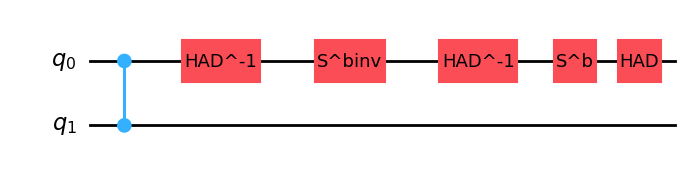

R14-rhs


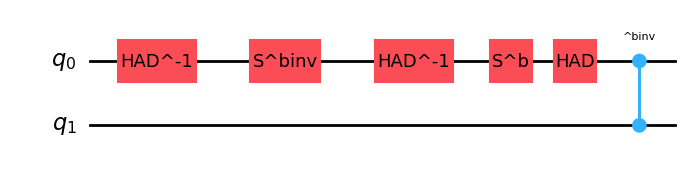

R14-1-lhs


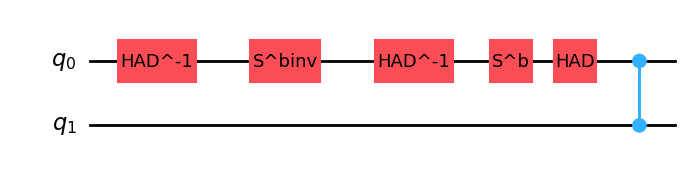

R14-1-rhs


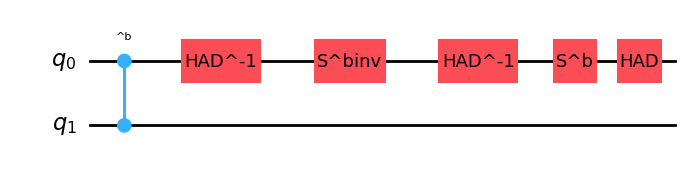

R14-2-lhs


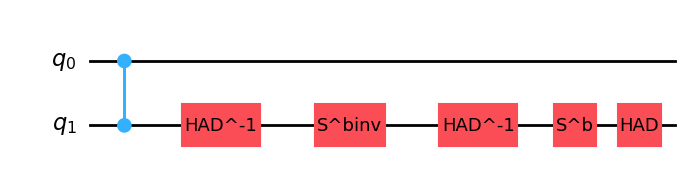

R14-2-rhs


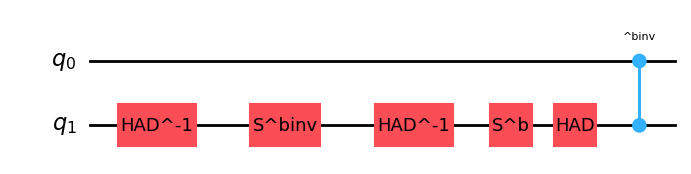

R14-3-lhs


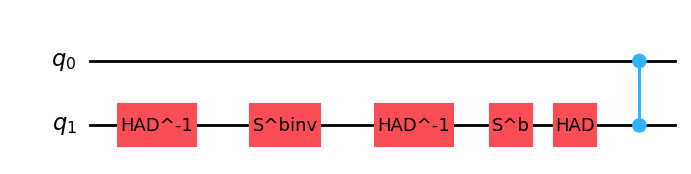

R14-3-rhs


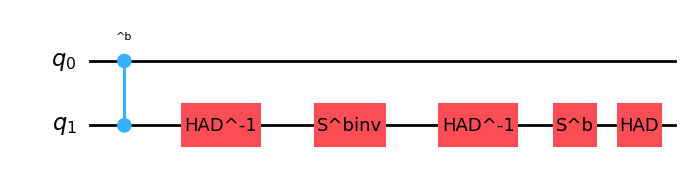

R14-4-lhs


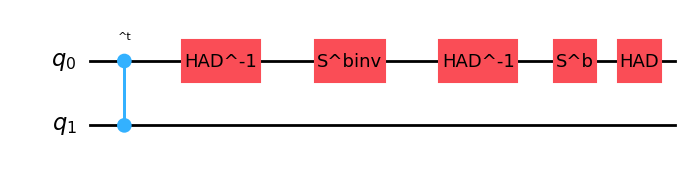

R14-4-rhs


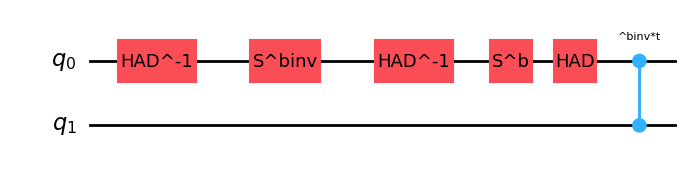

R14-5-lhs


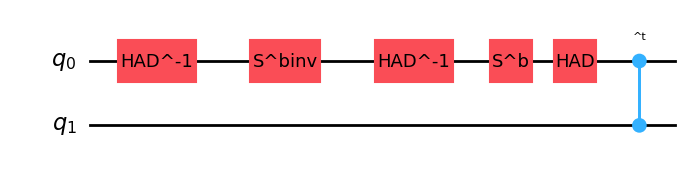

R14-5-rhs


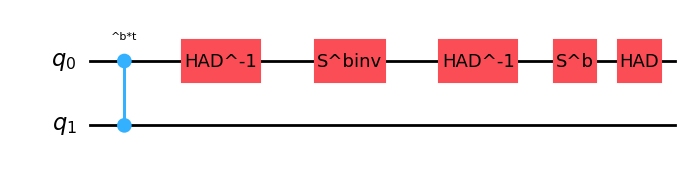

R14-6-lhs


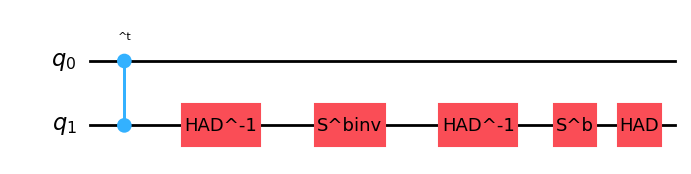

R14-6-rhs


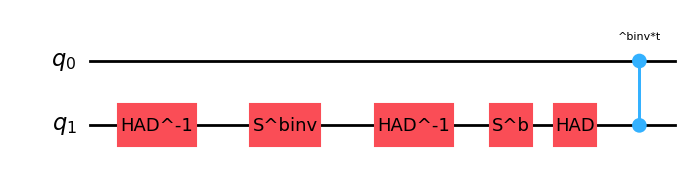

R14-7-lhs


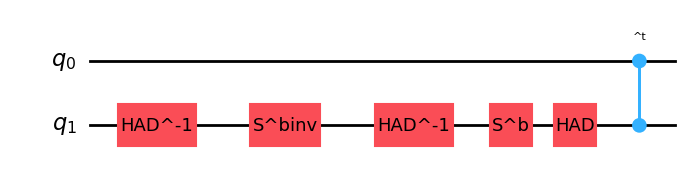

R14-7-rhs


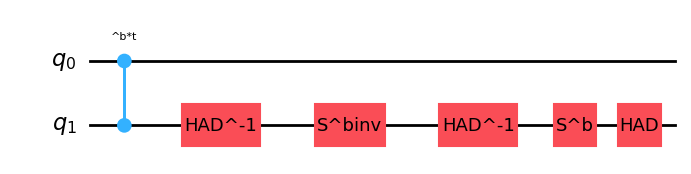

([Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), CZ(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^t(0,1), HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0), CZ^t(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^t(0,1), HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1)] gates),
  Circuit[23](2 qudits, 0 dits, [HAD^-1(1), S^binv(1), HAD^-1(1), S^b(1), HAD(1), CZ^t(0,1)] gates)],
 [Circuit[23](2 qudits, 0 dits, [HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0), CZ^binv(0,1)] gates),
  Circuit[23](2 qudits, 0 dits, [CZ^b(0,1), HAD^-1(0), S^binv(0), HAD^-1(0), S^b(0), HAD(0)] ga

In [57]:
generate_CZ_A0b(23)